# 卸料任务时间与能耗预测

本 Notebook 使用同一份数据和同一次训练集/测试集划分，比较三类模型：

1. **Baseline 1：里程比例模型**
2. **Baseline 2：普通线性回归**
3. **XGBoost：先在训练集上进行网格搜索，再使用最优模型预测测试集**

> XGBoost 不再额外训练一组手动默认参数模型，避免与网格搜索模型重复。

## 1. 导入依赖

**本单元功能**

- 导入数据处理、建模、评估、绘图和模型保存所需的库；
- 设置中文字体和表格显示选项。

首次运行前请确保已安装：

```bash
pip install pandas numpy matplotlib scikit-learn xgboost joblib
```

In [89]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from lightgbm import LGBMRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    cross_validate,
    train_test_split,
)
from xgboost import XGBRegressor

# 绘图显示设置：统一为简洁、适合报告的风格
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "white",
    "axes.facecolor": "#FAFAFA",
    "axes.edgecolor": "#D0D5DD",
    "axes.linewidth": 0.8,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "axes.grid": True,
    "grid.color": "#D0D5DD",
    "grid.alpha": 0.45,
    "grid.linestyle": "--",
    "legend.frameon": False,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.unicode_minus": False,
})
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei",
    "SimHei",
    "Arial Unicode MS",
    "DejaVu Sans",
]

MODEL_COLORS = {
    "XGBoost": "#1F77B4",
    "LightGBM": "#2CA02C",
    "HGBR": "#D62728",
    "随机森林": "#9467BD",
}

# 表格显示设置
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

print("依赖导入完成。")


依赖导入完成。


## 2. 配置数据路径、特征和训练参数

**本单元功能**

- 指定特征 JSON 文件目录和结果保存目录；
- 定义模型输入特征和两个预测目标；
- 设置训练集/测试集比例、随机种子和网格搜索折数。

通常只需要修改 `DATA_DIR` 和 `OUTPUT_DIR`。

In [90]:
# =========================
# 1. 文件路径
# =========================

# 特征 JSON 所在目录
DATA_DIR = Path(r"C:\Users\14993\PycharmProjects\BoLei-DataMining\data\FeatureData")

# 模型和结果保存目录
OUTPUT_DIR = Path(r"C:\Users\14993\PycharmProjects\BoLei-DataMining\target\ModelResults")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# =========================
# 2. 输入特征与预测目标
# =========================

FEATURE_COLS = [
    "departure_hour_sin",
    "departure_hour_cos",
    "total_distance_odometer_m",
    "total_altitude_change_m",
    "pitch_mean",
    "pitch_std",
    "speed_mean",
    "speed_std",
    "slope_sin_mean",
    "slope_sin_std",
    "straight_line_distance_m"
]

TIME_TARGET = "task_duration_s"
ENERGY_TARGET = "total_energy_soc_delta_pct"


# =========================
# 3. 数据划分与网格搜索设置
# =========================

TEST_SIZE = 0.2
RANDOM_STATE = 42
GRID_SEARCH_CV_FOLDS = 5

# GridSearchCV 并行进程数：
# -1 表示使用全部可用 CPU；如内存不足可改为 1。
GRID_SEARCH_N_JOBS = 4

print("数据目录：", DATA_DIR)
print("结果目录：", OUTPUT_DIR)
print(f"测试集比例：{TEST_SIZE:.0%}")
print(f"网格搜索交叉验证折数：{GRID_SEARCH_CV_FOLDS}")

数据目录： C:\Users\14993\PycharmProjects\BoLei-DataMining\data\FeatureData
结果目录： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\ModelResults
测试集比例：20%
网格搜索交叉验证折数：5


## 3. 读取并清洗全部 JSON 数据

**本单元功能**

- 递归读取 `DATA_DIR` 下的所有 JSON 文件；
- 兼容 `{"tasks": [...]}` 和直接任务列表 `[...]` 两种结构；
- 检查必要字段；
- 将特征和标签转换为数值；
- 删除缺失值、非正行程时间和负里程记录；
- 合并为一个 DataFrame。

**输出**

- `df`：清洗后的完整任务数据。

In [91]:
def load_dataset(data_dir):
    json_files = sorted(data_dir.rglob("*.json"))

    if not json_files:
        raise FileNotFoundError(f"没有找到 JSON 文件：{data_dir}")

    required_cols = FEATURE_COLS + [TIME_TARGET, ENERGY_TARGET]
    all_data = []
    skipped_files = []

    for json_file in json_files:
        try:
            with json_file.open("r", encoding="utf-8") as file:
                data = json.load(file)

            if isinstance(data, dict) and isinstance(data.get("tasks"), list):
                tasks = data["tasks"]
            elif isinstance(data, list):
                tasks = data
            else:
                skipped_files.append((json_file.name, "没有任务列表"))
                continue

            file_df = pd.DataFrame(tasks)

            missing_cols = [
                col for col in required_cols
                if col not in file_df.columns
            ]

            if missing_cols:
                skipped_files.append(
                    (json_file.name, f"缺少字段：{missing_cols}")
                )
                continue

            if "task_id" not in file_df.columns:
                file_df["task_id"] = pd.NA

            if "task_index" not in file_df.columns:
                file_df["task_index"] = pd.NA

            file_df["source_file"] = str(
                json_file.relative_to(data_dir)
            )

            keep_cols = (
                required_cols
                + ["task_id", "task_index", "source_file"]
            )
            all_data.append(file_df[keep_cols].copy())

        except Exception as error:
            skipped_files.append((json_file.name, str(error)))

    if not all_data:
        raise ValueError("没有成功读取任何可用数据。")

    dataset = pd.concat(all_data, ignore_index=True)

    for col in required_cols:
        dataset[col] = pd.to_numeric(dataset[col], errors="coerce")

    original_count = len(dataset)

    dataset = dataset.dropna(subset=required_cols)
    dataset = dataset[
        (dataset["total_distance_odometer_m"] >= 0)
        & (dataset[TIME_TARGET] > 0)
    ].reset_index(drop=True)

    print(f"发现 JSON 文件数：{len(json_files)}")
    print(f"成功读取文件数：{len(all_data)}")
    print(f"原始任务数：{original_count}")
    print(f"有效任务数：{len(dataset)}")
    print(f"删除无效任务数：{original_count - len(dataset)}")

    if skipped_files:
        print(f"\n跳过文件数：{len(skipped_files)}")
        for file_name, reason in skipped_files:
            print(f"- {file_name}: {reason}")

    return dataset


df = load_dataset(DATA_DIR)

发现 JSON 文件数：20
成功读取文件数：20
原始任务数：3210
有效任务数：3210
删除无效任务数：0


## 4. 查看数据概况

**本单元功能**

- 查看合并后的数据规模和文件数量；
- 预览前几条任务；
- 检查各特征和标签的统计分布。

此单元只用于数据检查，不参与模型训练。

In [92]:
print("数据形状：", df.shape)
print("数据文件数：", df["source_file"].nunique())

display(df.head())

summary_cols = FEATURE_COLS + [TIME_TARGET, ENERGY_TARGET]
display(df[summary_cols].describe().T.round(4))

数据形状： (3210, 16)
数据文件数： 20


,departure_hour_sin,departure_hour_cos,total_distance_odometer_m,total_altitude_change_m,pitch_mean,pitch_std,speed_mean,speed_std,slope_sin_mean,slope_sin_std,straight_line_distance_m,task_duration_s,total_energy_soc_delta_pct,task_id,task_index,source_file
0,-0.456174,-0.889890,3500.0,144.5831,-1.928053,2.509720,3.297326,1.592501,0.041162,0.032420,2349.129850,1078.880390,14.8,8061955916906753,1,TLE00860CR1450020卸料任务_特征和标签.json
1,-0.914676,0.404187,4500.0,132.5124,-1.727225,2.499827,4.281888,2.113034,0.029442,0.034638,2931.200681,1078.446503,13.6,8062296833835265,2,TLE00860CR1450020卸料任务_特征和标签.json
2,-0.695656,0.718375,4125.0,172.0542,-2.281552,2.496671,3.504632,1.329558,0.041521,0.029248,2117.307809,1218.586187,16.0,8062383657042177,3,TLE00860CR1450020卸料任务_特征和标签.json
3,-0.521993,0.852950,3500.0,144.3345,-1.711009,2.469314,3.076494,1.659597,0.041108,0.028335,2320.774277,1193.786143,12.8,8062433255342337,4,TLE00860CR1450020卸料任务_特征和标签.json
4,-0.110991,0.993821,5125.0,161.8966,-2.033794,2.352843,4.059008,2.049870,0.031554,0.034708,2648.932888,1303.056854,16.0,8062531927441665,5,TLE00860CR1450020卸料任务_特征和标签.json


,count,mean,std,min,25%,50%,75%,max
departure_hour_sin,3210.0,0.0160,0.6976,-1.0000,-0.6525,0.0243,0.6966,1.0000
departure_hour_cos,3210.0,0.0622,0.7138,-1.0000,-0.6816,0.1170,0.7845,1.0000
total_distance_odometer_m,3210.0,3894.2757,652.4424,2500.0000,3375.0000,3875.0000,4375.0000,6125.0000
total_altitude_change_m,3210.0,147.0768,24.6324,101.2538,123.3096,146.1561,173.5772,192.8145
pitch_mean,3210.0,-1.9226,0.8203,-4.4335,-2.5663,-1.8409,-1.3656,0.4365
pitch_std,3210.0,2.4155,0.1696,1.7874,2.2971,2.4035,2.5270,3.6636
speed_mean,3210.0,3.4036,0.2928,1.6608,3.2678,3.4211,3.5527,4.2819
speed_std,3210.0,1.5800,0.2456,0.6206,1.3972,1.5347,1.7016,2.6924
slope_sin_mean,3210.0,0.0380,0.0049,0.0247,0.0346,0.0384,0.0413,0.0513
slope_sin_std,3210.0,0.0316,0.0030,0.0231,0.0294,0.0313,0.0335,0.0441


## 5. 统一划分训练集和测试集

**本单元功能**

- 按相同索引划分训练集和测试集；
- 为时间预测和能耗预测准备相同的输入特征；
- 保证所有模型在同一批测试样本上比较。

**输出**

- `X_train`、`X_test`
- `y_time_train`、`y_time_test`
- `y_energy_train`、`y_energy_test`

In [93]:
train_index, test_index = train_test_split(
    df.index,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

train_df = df.loc[train_index].reset_index(drop=True)
test_df = df.loc[test_index].reset_index(drop=True)

X_train = train_df[FEATURE_COLS]
X_test = test_df[FEATURE_COLS]

y_time_train = train_df[TIME_TARGET]
y_time_test = test_df[TIME_TARGET]

y_energy_train = train_df[ENERGY_TARGET]
y_energy_test = test_df[ENERGY_TARGET]

print(f"训练集样本数：{len(train_df)}")
print(f"测试集样本数：{len(test_df)}")

训练集样本数：2568
测试集样本数：642


## 6. 定义评估和绘图函数

**本单元功能**

- `get_metrics`：计算 MAE、RMSE 和 R²；
- `plot_actual_vs_predicted`：绘制真实值与预测值散点图；
- `plot_residuals`：绘制预测残差图。

这些函数会被后续所有模型重复调用。

In [94]:
def get_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
    }


def plot_actual_vs_predicted(
    y_true,
    y_pred,
    title,
    unit,
    color="#1F77B4",
):
    """绘制真实值与预测值，并保持两个坐标轴同比例。"""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    min_value = min(y_true.min(), y_pred.min())
    max_value = max(y_true.max(), y_pred.max())
    padding = max((max_value - min_value) * 0.06, 1e-9)
    lower = min_value - padding
    upper = max_value + padding

    fig, ax = plt.subplots(figsize=(7.2, 5.2))
    ax.scatter(
        y_true,
        y_pred,
        s=52,
        alpha=0.72,
        color=color,
        edgecolors="white",
        linewidths=0.6,
        label="测试样本",
        zorder=3,
    )
    ax.plot(
        [lower, upper],
        [lower, upper],
        linestyle="--",
        linewidth=1.8,
        color="#344054",
        label="理想预测线",
        zorder=2,
    )
    ax.set_xlim(lower, upper)
    ax.set_ylim(lower, upper)
    # ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(f"真实值（{unit}）")
    ax.set_ylabel(f"预测值（{unit}）")
    ax.set_title(title, pad=14)
    ax.legend(loc="best")
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    plt.show()


def plot_residuals(
    y_true,
    y_pred,
    title,
    unit,
    color="#1F77B4",
):
    """绘制残差图；残差定义为预测值减真实值。"""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    residuals = y_pred - y_true

    fig, ax = plt.subplots(figsize=(7.2, 5.2))
    ax.scatter(
        y_pred,
        residuals,
        s=52,
        alpha=0.72,
        color=color,
        edgecolors="white",
        linewidths=0.6,
        zorder=3,
    )
    ax.axhline(
        0,
        linestyle="--",
        linewidth=1.8,
        color="#344054",
    )
    ax.set_xlabel(f"预测值（{unit}）")
    ax.set_ylabel(f"残差（{unit}）")
    ax.set_title(title, pad=14)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    plt.show()


def plot_feature_importance(
    importance_df,
    title,
    xlabel="特征重要性",
    color="#1F77B4",
):
    """统一绘制横向特征重要性图。"""
    plot_df = importance_df.sort_values("importance").copy()

    fig_height = max(5.2, 0.42 * len(plot_df) + 1.5)
    fig, ax = plt.subplots(figsize=(8.2, fig_height))
    bars = ax.barh(
        plot_df["feature"],
        plot_df["importance"],
        color=color,
        alpha=0.88,
    )

    max_value = float(plot_df["importance"].max()) if len(plot_df) else 0
    for bar, value in zip(bars, plot_df["importance"]):
        ax.text(
            bar.get_width() + max_value * 0.012,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.3f}",
            va="center",
            fontsize=9,
        )

    ax.set_xlabel(xlabel)
    ax.set_ylabel("特征")
    ax.set_title(title, pad=14)
    ax.grid(axis="y", visible=False)
    ax.spines[["top", "right", "left"]].set_visible(False)
    fig.tight_layout()
    plt.show()


# 7. Baseline 1：里程比例模型

假设任务时间和能耗分别与行驶里程成正比：

\[
\hat{t}=k_t d
\]

\[
\hat{e}=k_e d
\]

## 7.1 拟合比例系数

**本单元功能**

- 只使用训练集估计时间比例系数和能耗比例系数；
- 不使用测试集信息；
- 输出每米、每公里对应的时间和能耗。

In [95]:
distance_train = train_df["total_distance_odometer_m"].to_numpy()
time_train = y_time_train.to_numpy()
energy_train = y_energy_train.to_numpy()

denominator = np.sum(distance_train ** 2)

if denominator == 0:
    raise ValueError("训练集里程全部为 0，无法拟合里程比例模型。")

baseline1_time_k = (
    np.sum(distance_train * time_train)
    / denominator
)

baseline1_energy_k = (
    np.sum(distance_train * energy_train)
    / denominator
)

print(f"时间比例系数：{baseline1_time_k:.8f} 秒/米")
print(f"每公里预测时间：{baseline1_time_k * 1000:.4f} 秒/公里")

if baseline1_time_k > 0:
    constant_speed = 3.6 / baseline1_time_k
    print(f"对应的等效恒定速度：{constant_speed:.4f} km/h")

print(
    f"能耗比例系数："
    f"{baseline1_energy_k:.10f} SOC 百分点/米"
)
print(
    f"每公里预测能耗："
    f"{baseline1_energy_k * 1000:.6f} SOC 百分点/公里"
)

时间比例系数：0.30766764 秒/米
每公里预测时间：307.6676 秒/公里
对应的等效恒定速度：11.7009 km/h
能耗比例系数：0.0037272485 SOC 百分点/米
每公里预测能耗：3.727248 SOC 百分点/公里


## 7.2 预测测试集并计算指标

**本单元功能**

- 使用训练集得到的两个比例系数预测测试集；
- 计算时间和能耗的 MAE、RMSE、R²；
- 生成后续保存模型所需的比例模型字典。

In [96]:
baseline1_time_pred = (
    baseline1_time_k
    * test_df["total_distance_odometer_m"].to_numpy()
)

baseline1_energy_pred = (
    baseline1_energy_k
    * test_df["total_distance_odometer_m"].to_numpy()
)

baseline1_time_metrics = get_metrics(
    y_time_test,
    baseline1_time_pred,
)

baseline1_energy_metrics = get_metrics(
    y_energy_test,
    baseline1_energy_pred,
)

baseline1_model_data = {
    "model_name": "distance_proportional_time_and_energy_baseline",
    "distance_feature": "total_distance_odometer_m",
    "time": {
        "formula": (
            "predicted_task_duration_s = "
            "time_coefficient_s_per_m * "
            "total_distance_odometer_m"
        ),
        "time_coefficient_s_per_m": float(baseline1_time_k),
        "time_coefficient_s_per_km": float(
            baseline1_time_k * 1000
        ),
    },
    "energy": {
        "formula": (
            "predicted_energy_soc_pct = "
            "energy_coefficient_soc_pct_per_m * "
            "total_distance_odometer_m"
        ),
        "energy_coefficient_soc_pct_per_m": float(
            baseline1_energy_k
        ),
        "energy_coefficient_soc_pct_per_km": float(
            baseline1_energy_k * 1000
        ),
    },
    "train_sample_count": len(train_df),
}

print("任务时间测试集指标：")
display(pd.DataFrame(
    [baseline1_time_metrics],
    index=["里程比例 Baseline"],
).round(4))

print("行程能耗测试集指标：")
display(pd.DataFrame(
    [baseline1_energy_metrics],
    index=["里程比例 Baseline"],
).round(4))

任务时间测试集指标：


,MAE,RMSE,R2
里程比例 Baseline,98.5729,137.0994,0.5025


行程能耗测试集指标：


,MAE,RMSE,R2
里程比例 Baseline,1.4137,1.7477,0.5392


## 7.3 查看逐条预测和误差图

**本单元功能**

- 展示测试集前 10 条预测；
- 计算预测值减真实值的残差；
- 绘制时间和能耗的拟合图及残差图。

,task_id,source_file,total_distance_odometer_m,task_duration_s,total_energy_soc_delta_pct,pred_task_duration_s,time_residual_s,pred_energy_soc_pct,energy_residual_soc_pct
0,8065986810708225,TLE00860HR1450010卸料任务_特征和标签.json,3375.0,1002.1024,14.4,1038.3783,36.2759,12.5795,-1.8205
1,8066176061194497,TLE00900CR1450050卸料任务_特征和标签.json,4375.0,1409.4458,18.4,1346.0459,-63.3998,16.3067,-2.0933
2,8094951438336257,TLE00900VR1450048最终有效卸货记录615-707_sorted_特征和标签....,3250.0,1025.8506,13.2,999.9198,-25.9308,12.1136,-1.0864
3,8062584127078657,TLE00900JR1450046卸料任务_特征和标签.json,3250.0,1140.1710,13.6,999.9198,-140.2511,12.1136,-1.4864
4,8099212179472641,TLE00860VR1450018最终有效卸货记录615-707_sorted_特征和标签....,3500.0,1194.9745,12.0,1076.8368,-118.1377,13.0454,1.0454
5,8066256954654977,TLE00900AR1450052卸料任务_特征和标签.json,5250.0,1426.3102,18.0,1615.2551,188.9449,19.5681,1.5681
6,8087961773113601,TLE00860HR1450010最终有效卸货记录615-707_sorted_特征和标签....,4125.0,1113.0407,12.8,1269.1290,156.0883,15.3749,2.5749
7,8101046186524929,TLE00900CR1450050最终有效卸货记录615-707_sorted_特征和标签....,3125.0,1303.7853,12.8,961.4614,-342.3239,11.6477,-1.1523
8,8065180703752449,TLE00860HR1450010卸料任务_特征和标签.json,3875.0,1203.6099,16.8,1192.2121,-11.3978,14.4431,-2.3569
9,8085294128709889,TLE00900AR1450049最终有效卸货记录615-707_sorted_特征和标签....,4375.0,1291.9774,17.6,1346.0459,54.0685,16.3067,-1.2933


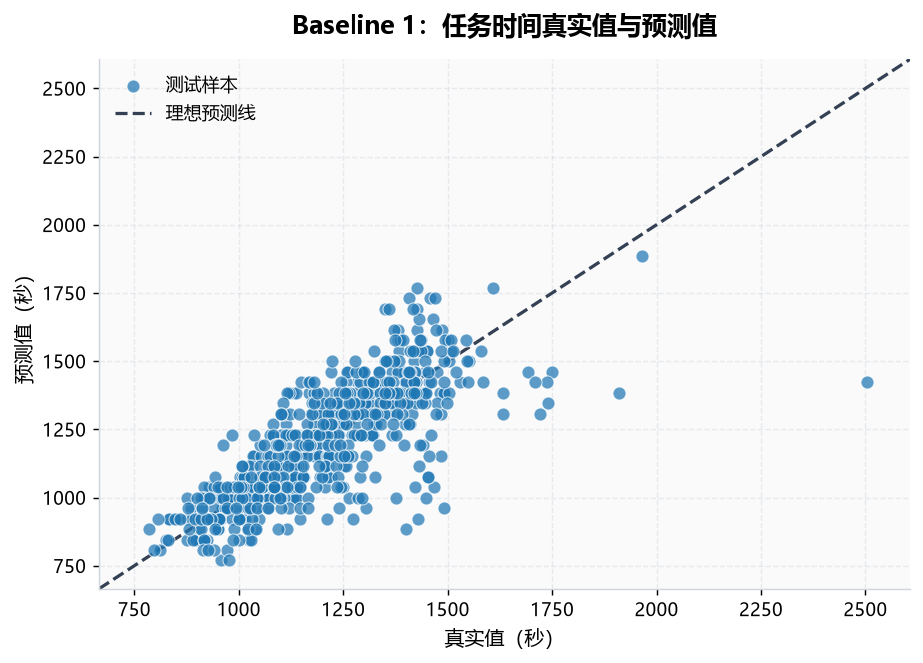

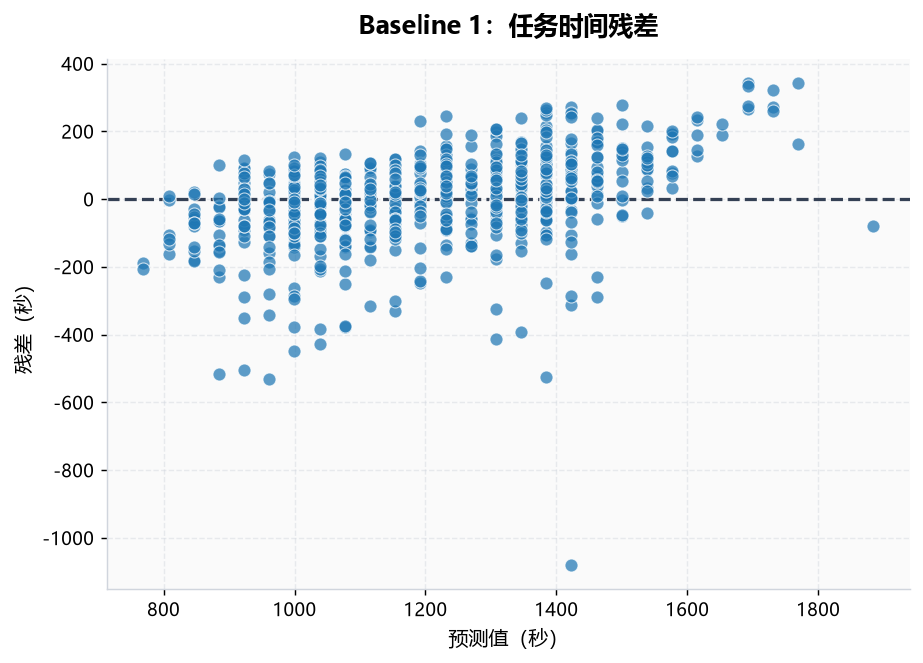

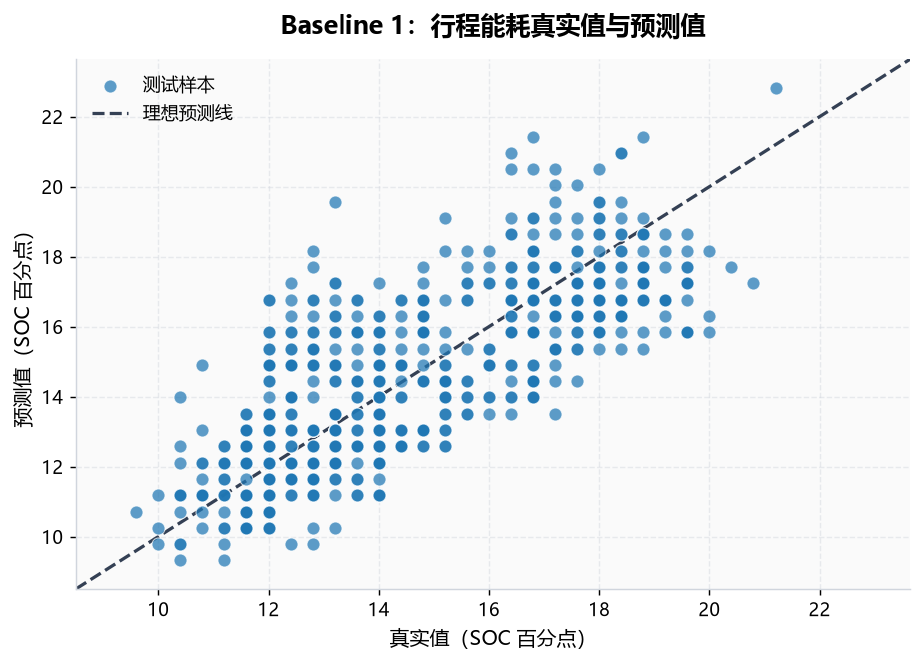

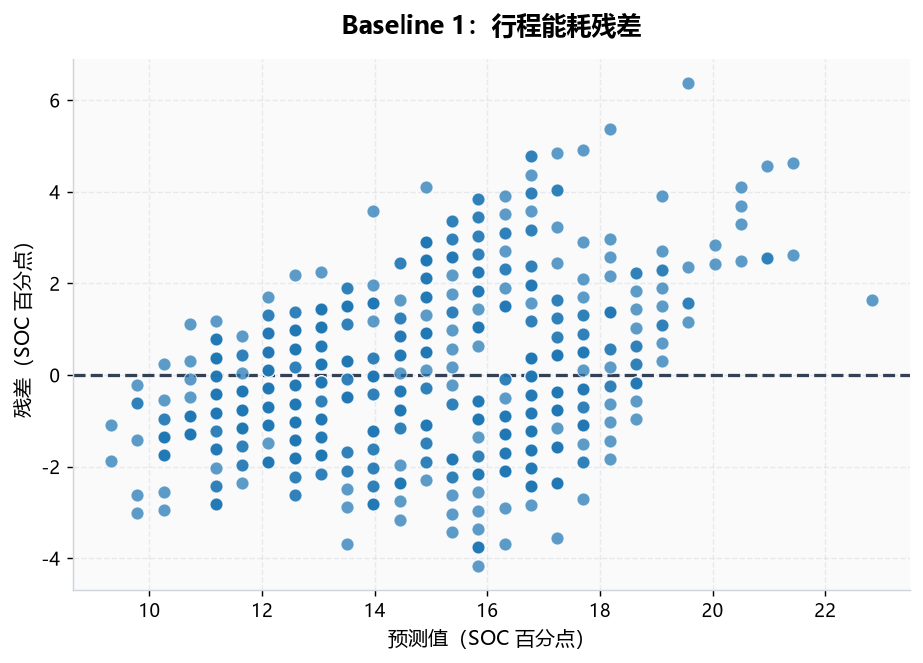

In [97]:
baseline1_preview = test_df[
    [
        "task_id",
        "source_file",
        "total_distance_odometer_m",
        TIME_TARGET,
        ENERGY_TARGET,
    ]
].copy()

baseline1_preview["pred_task_duration_s"] = baseline1_time_pred
baseline1_preview["time_residual_s"] = (
    baseline1_preview["pred_task_duration_s"]
    - baseline1_preview[TIME_TARGET]
)

baseline1_preview["pred_energy_soc_pct"] = baseline1_energy_pred
baseline1_preview["energy_residual_soc_pct"] = (
    baseline1_preview["pred_energy_soc_pct"]
    - baseline1_preview[ENERGY_TARGET]
)

display(baseline1_preview.head(10).round(4))

plot_actual_vs_predicted(
    y_time_test,
    baseline1_time_pred,
    "Baseline 1：任务时间真实值与预测值",
    "秒",
)
plot_residuals(
    y_time_test,
    baseline1_time_pred,
    "Baseline 1：任务时间残差",
    "秒",
)

plot_actual_vs_predicted(
    y_energy_test,
    baseline1_energy_pred,
    "Baseline 1：行程能耗真实值与预测值",
    "SOC 百分点",
)
plot_residuals(
    y_energy_test,
    baseline1_energy_pred,
    "Baseline 1：行程能耗残差",
    "SOC 百分点",
)

# 8. Baseline 2：普通线性回归

## 8.1 训练并评估时间模型和能耗模型

**本单元功能**

- 使用全部特征分别训练时间线性回归和能耗线性回归；
- 在测试集上预测；
- 计算两个模型的 MAE、RMSE 和 R²。

In [98]:
# 时间线性回归
linear_time_model = LinearRegression()
linear_time_model.fit(X_train, y_time_train)
linear_time_pred = linear_time_model.predict(X_test)
linear_time_metrics = get_metrics(
    y_time_test,
    linear_time_pred,
)

# 能耗线性回归
linear_energy_model = LinearRegression()
linear_energy_model.fit(X_train, y_energy_train)
linear_energy_pred = linear_energy_model.predict(X_test)
linear_energy_metrics = get_metrics(
    y_energy_test,
    linear_energy_pred,
)

print("任务时间线性回归：")
display(pd.DataFrame(
    [linear_time_metrics],
    index=["线性回归"],
).round(4))

print("能耗线性回归：")
display(pd.DataFrame(
    [linear_energy_metrics],
    index=["线性回归"],
).round(4))

任务时间线性回归：


,MAE,RMSE,R2
线性回归,32.1469,45.1877,0.946


能耗线性回归：


,MAE,RMSE,R2
线性回归,0.6132,0.8012,0.9032


## 8.2 查看线性回归系数

**本单元功能**

- 输出时间模型和能耗模型的截距；
- 按系数绝对值排序展示各特征系数。

注意：不同特征量纲不同，原始系数大小不能直接等同于特征重要性。

In [99]:
linear_time_coef = pd.DataFrame({
    "feature": FEATURE_COLS,
    "coefficient": linear_time_model.coef_,
})

linear_energy_coef = pd.DataFrame({
    "feature": FEATURE_COLS,
    "coefficient": linear_energy_model.coef_,
})

print(f"任务时间模型截距：{linear_time_model.intercept_:.6f}")
display(
    linear_time_coef
    .sort_values("coefficient", key=abs, ascending=False)
    .round(6)
)

print(f"能耗模型截距：{linear_energy_model.intercept_:.6f}")
display(
    linear_energy_coef
    .sort_values("coefficient", key=abs, ascending=False)
    .round(6)
)

任务时间模型截距：1109.480644


,feature,coefficient
9,slope_sin_std,6591.773599
6,speed_mean,-432.661809
8,slope_sin_mean,-193.497614
7,speed_std,70.010944
5,pitch_std,-8.109228
4,pitch_mean,5.343619
0,departure_hour_sin,-2.856174
3,total_altitude_change_m,1.420790
1,departure_hour_cos,-0.263702
2,total_distance_odometer_m,0.242490


能耗模型截距：-1.534950


,feature,coefficient
8,slope_sin_mean,-38.675805
9,slope_sin_std,31.149198
6,speed_mean,-0.473447
5,pitch_std,0.472288
7,speed_std,0.399142
4,pitch_mean,-0.103010
3,total_altitude_change_m,0.089627
1,departure_hour_cos,0.067811
0,departure_hour_sin,-0.058084
2,total_distance_odometer_m,0.000620


## 8.3 绘制线性回归预测结果

**本单元功能**

- 绘制任务时间真实值—预测值图和残差图；
- 绘制能耗真实值—预测值图和残差图。

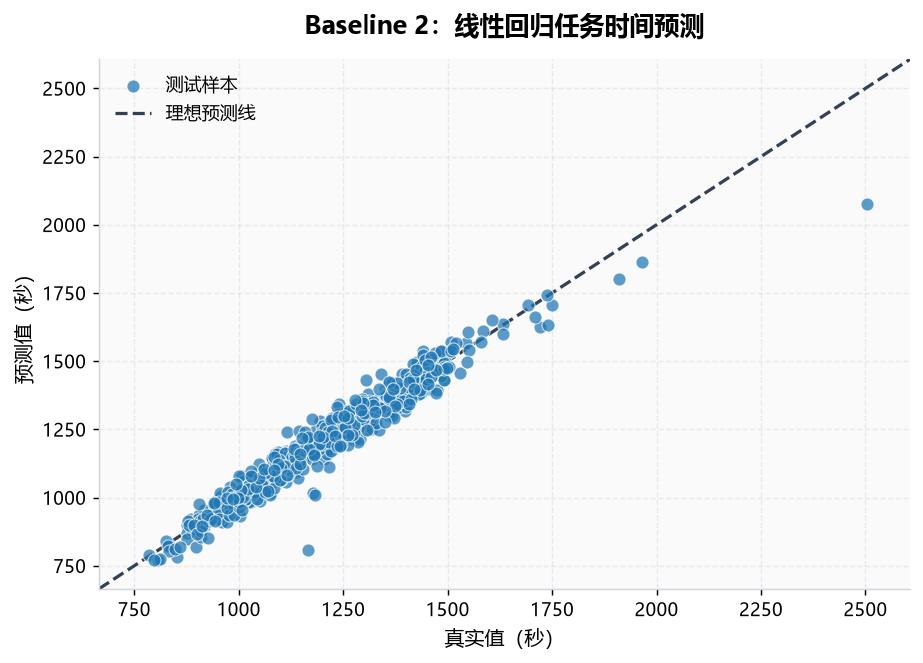

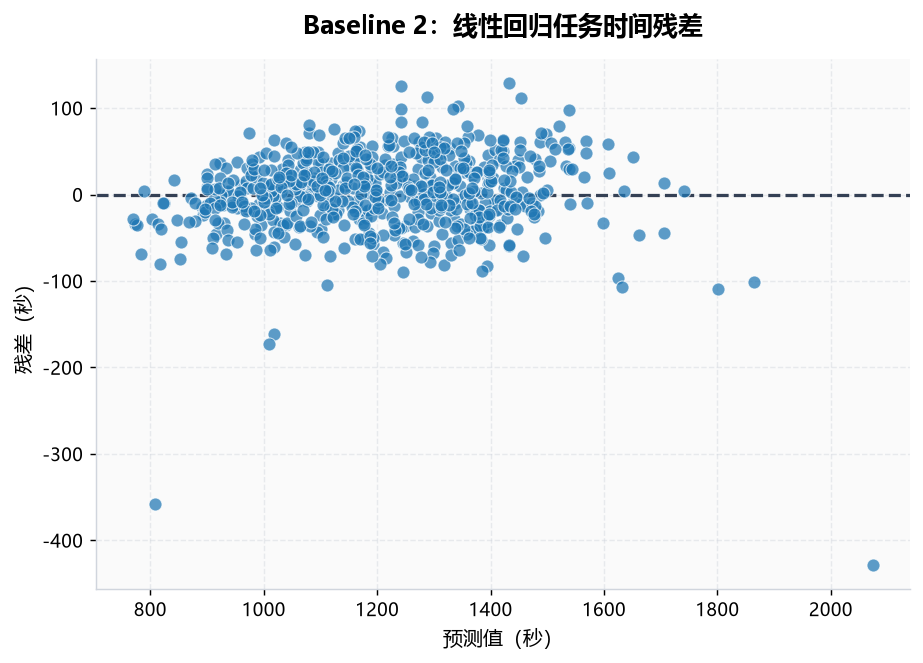

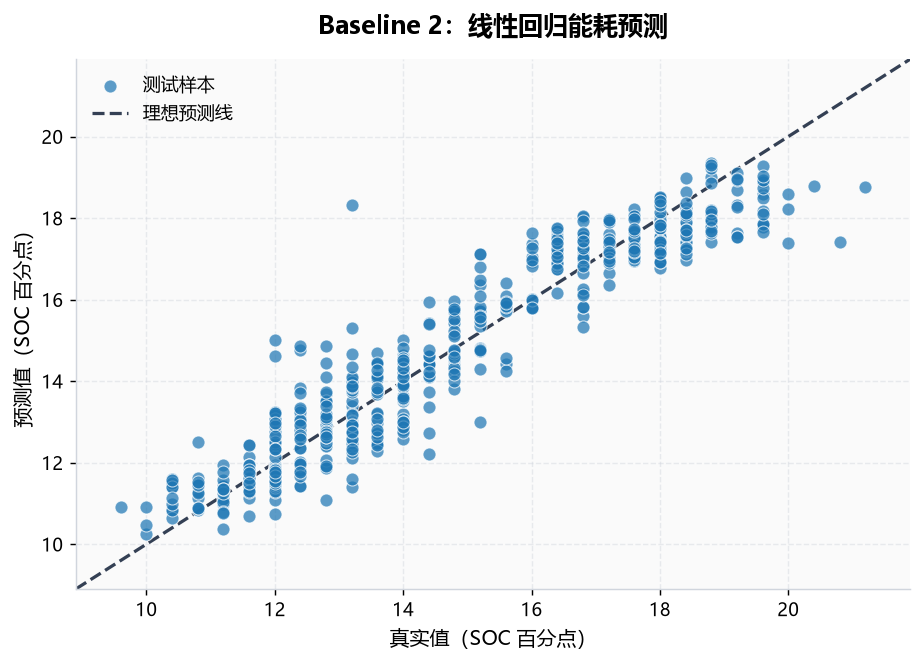

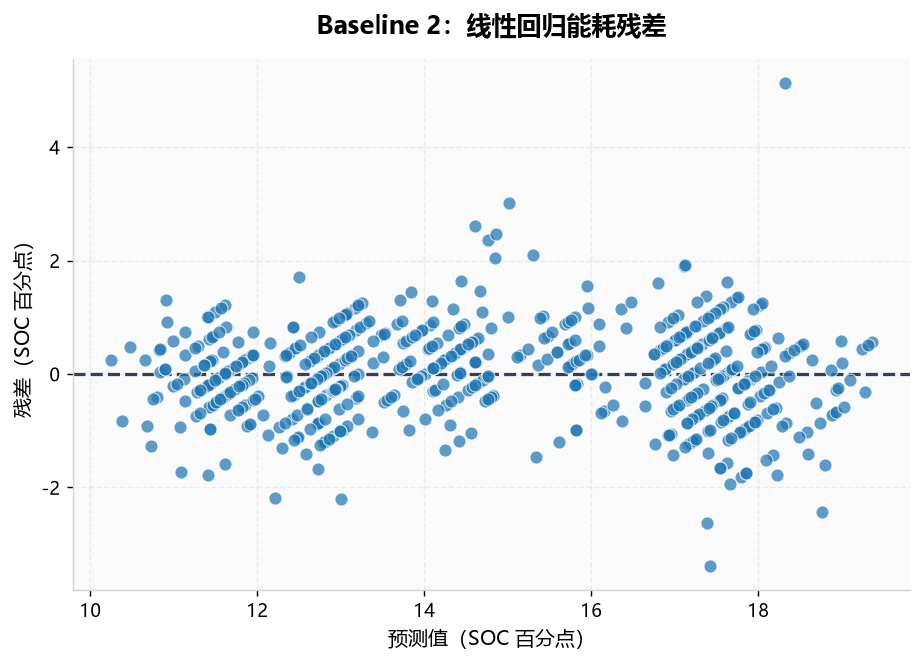

In [100]:
plot_actual_vs_predicted(
    y_time_test,
    linear_time_pred,
    "Baseline 2：线性回归任务时间预测",
    "秒",
)
plot_residuals(
    y_time_test,
    linear_time_pred,
    "Baseline 2：线性回归任务时间残差",
    "秒",
)

plot_actual_vs_predicted(
    y_energy_test,
    linear_energy_pred,
    "Baseline 2：线性回归能耗预测",
    "SOC 百分点",
)
plot_residuals(
    y_energy_test,
    linear_energy_pred,
    "Baseline 2：线性回归能耗残差",
    "SOC 百分点",
)

# 9. XGBoost：网格搜索后训练最优模型

流程如下：

1. 定义待搜索参数；
2. 只在训练集上进行交叉验证；
3. 时间目标和能耗目标分别搜索；
4. `GridSearchCV(refit=True)` 自动使用最佳参数在完整训练集上重新拟合；
5. 最优模型预测测试集。

不再训练额外的“默认参数 XGBoost”。

## 9.1 定义参数网格和交叉验证策略

**本单元功能**

- 定义 XGBoost 参数候选值；
- 计算参数组合数量；
- 创建仅用于训练集网格搜索的 K 折交叉验证器。

树数量、树深、学习率和采样比例由网格搜索选择；正则化相关参数沿用原方案作为固定设置。

In [101]:
xgb_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.03, 0.05, 0.10],
    "subsample": [0.80, 0.90, 1.00],
    "colsample_bytree": [0.80, 0.90, 1.00],
}

grid_size = int(np.prod([
    len(values)
    for values in xgb_param_grid.values()
]))

search_cv_folds = min(
    GRID_SEARCH_CV_FOLDS,
    len(X_train) // 2,
)

if search_cv_folds < 2:
    raise ValueError("训练样本太少，无法进行网格搜索。")

search_cv = KFold(
    n_splits=search_cv_folds,
    shuffle=True,
    random_state=RANDOM_STATE,
)

print(f"参数组合数：{grid_size}")
print(f"每个目标需要拟合：{grid_size * search_cv_folds} 次")
print(f"使用 {search_cv_folds} 折交叉验证。")

参数组合数：324
每个目标需要拟合：1620 次
使用 5 折交叉验证。


> 当前参数网格组合较多。若运行时间过长，可先缩小每个列表的候选值，再围绕第一轮最优参数进行第二轮细化搜索。

## 9.2 搜索任务时间模型的最优参数

**本单元功能**

- 对任务时间标签执行网格搜索；
- 使用训练集交叉验证 RMSE 选择参数；
- 自动在完整训练集上重新拟合最佳模型；
- 输出最佳参数和最佳交叉验证 RMSE。

**输出**

- `time_grid_search`
- `xgb_time_model`

In [102]:
time_grid_search = GridSearchCV(
    estimator=XGBRegressor(
        objective="reg:squarederror",
        min_child_weight=2,
        reg_alpha=0.1,
        reg_lambda=3.0,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    param_grid=xgb_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=search_cv,
    n_jobs=GRID_SEARCH_N_JOBS,
    verbose=1,
    return_train_score=True,
    refit=True,
)

time_grid_search.fit(X_train, y_time_train)

# best_estimator_ 已使用最佳参数在完整训练集上重新拟合
xgb_time_model = time_grid_search.best_estimator_

print("任务时间最优参数：")
display(pd.DataFrame(
    list(time_grid_search.best_params_.items()),
    columns=["parameter", "best_value"],
))

print(
    "任务时间最优训练集 CV RMSE："
    f"{-time_grid_search.best_score_:.4f} 秒"
)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
任务时间最优参数：


,parameter,best_value
0,colsample_bytree,1.0
1,learning_rate,0.1
2,max_depth,5.0
3,n_estimators,300.0
4,subsample,0.9


任务时间最优训练集 CV RMSE：35.8599 秒


## 9.3 查看任务时间网格搜索前 10 组结果

**本单元功能**

- 将完整搜索结果转换为 DataFrame；
- 按交叉验证排名选出前 10 组；
- 展示各组合的 RMSE、波动和参数。

,组合,CV_RMSE,std_test_score,params
322,组合 1,35.8599,2.1750,"{'colsample_bytree': 1.0, 'learning_rate': 0.1..."
321,组合 2,35.8718,1.4177,"{'colsample_bytree': 1.0, 'learning_rate': 0.1..."
294,组合 3,36.0029,1.5980,"{'colsample_bytree': 1.0, 'learning_rate': 0.0..."
318,组合 4,36.1758,1.5018,"{'colsample_bytree': 1.0, 'learning_rate': 0.1..."
319,组合 5,36.2581,2.2238,"{'colsample_bytree': 1.0, 'learning_rate': 0.1..."
295,组合 6,36.3044,1.8550,"{'colsample_bytree': 1.0, 'learning_rate': 0.0..."
313,组合 7,36.3098,1.8133,"{'colsample_bytree': 1.0, 'learning_rate': 0.1..."
312,组合 8,36.3149,1.3242,"{'colsample_bytree': 1.0, 'learning_rate': 0.1..."
323,组合 9,36.3678,1.3789,"{'colsample_bytree': 1.0, 'learning_rate': 0.1..."
314,组合 10,36.5813,2.1721,"{'colsample_bytree': 1.0, 'learning_rate': 0.1..."


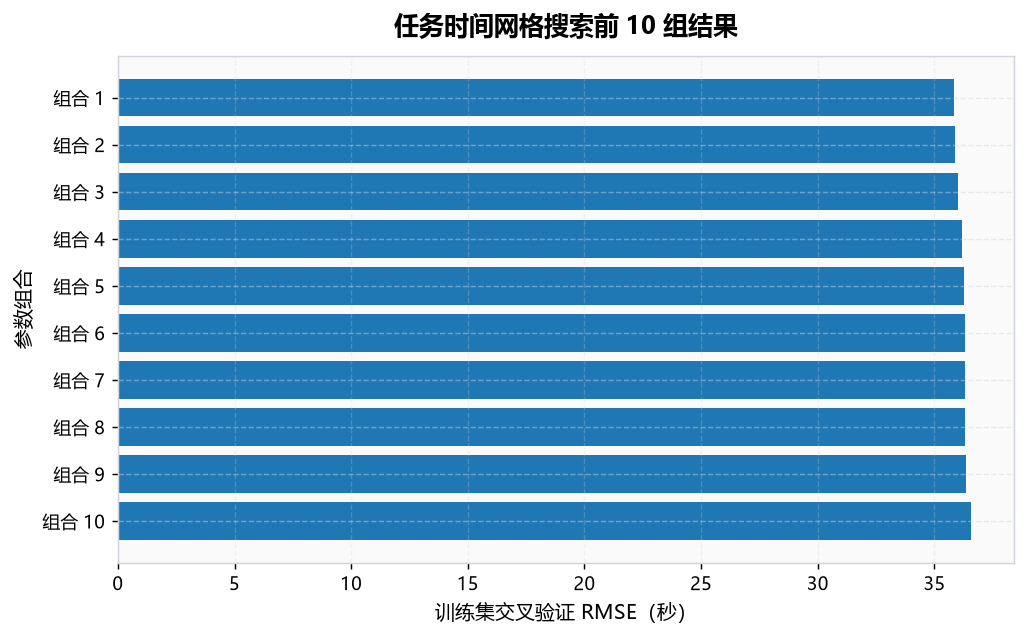

In [103]:
time_grid_results = pd.DataFrame(
    time_grid_search.cv_results_
)

time_grid_results["CV_RMSE"] = (
    -time_grid_results["mean_test_score"]
)

time_grid_top10 = (
    time_grid_results
    .sort_values("rank_test_score")
    .head(10)
    .copy()
)

time_grid_top10["组合"] = [
    f"组合 {index}"
    for index in range(1, len(time_grid_top10) + 1)
]

display(
    time_grid_top10[
        ["组合", "CV_RMSE", "std_test_score", "params"]
    ].round(4)
)

plt.figure(figsize=(8, 5))
plt.barh(
    time_grid_top10["组合"][::-1],
    time_grid_top10["CV_RMSE"][::-1],
)
plt.xlabel("训练集交叉验证 RMSE（秒）")
plt.ylabel("参数组合")
plt.title("任务时间网格搜索前 10 组结果", fontsize=14, pad=12)
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## 9.4 搜索能耗模型的最优参数

**本单元功能**

- 对能耗标签单独执行网格搜索；
- 不直接复用任务时间模型参数；
- 自动在完整训练集上重新拟合最佳模型；
- 输出最佳参数和最佳交叉验证 RMSE。

**输出**

- `energy_grid_search`
- `xgb_energy_model`

In [104]:
energy_grid_search = GridSearchCV(
    estimator=XGBRegressor(
        objective="reg:squarederror",
        min_child_weight=2,
        reg_alpha=0.1,
        reg_lambda=3.0,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    param_grid=xgb_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=search_cv,
    n_jobs=GRID_SEARCH_N_JOBS,
    verbose=1,
    return_train_score=True,
    refit=True,
)

energy_grid_search.fit(X_train, y_energy_train)

# best_estimator_ 已使用最佳参数在完整训练集上重新拟合
xgb_energy_model = energy_grid_search.best_estimator_

print("能耗最优参数：")
display(pd.DataFrame(
    list(energy_grid_search.best_params_.items()),
    columns=["parameter", "best_value"],
))

print(
    "能耗最优训练集 CV RMSE："
    f"{-energy_grid_search.best_score_:.4f} SOC 百分点"
)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
能耗最优参数：


,parameter,best_value
0,colsample_bytree,0.80
1,learning_rate,0.05
2,max_depth,5.00
3,n_estimators,200.00
4,subsample,1.00


能耗最优训练集 CV RMSE：0.7534 SOC 百分点


## 9.5 查看能耗网格搜索前 10 组结果

**本单元功能**

- 整理能耗模型的全部搜索结果；
- 展示交叉验证表现最好的前 10 组参数；
- 绘制前 10 组 RMSE 对比图。

,组合,CV_RMSE,std_test_score,params
77,组合 1,0.7534,0.0418,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."
51,组合 2,0.7535,0.0435,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."
48,组合 3,0.7539,0.0449,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."
264,组合 4,0.7542,0.0433,"{'colsample_bytree': 1.0, 'learning_rate': 0.0..."
49,组合 5,0.7545,0.0439,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."
316,组合 6,0.7547,0.0363,"{'colsample_bytree': 1.0, 'learning_rate': 0.1..."
265,组合 7,0.7549,0.0412,"{'colsample_bytree': 1.0, 'learning_rate': 0.0..."
161,组合 8,0.7551,0.0436,"{'colsample_bytree': 0.9, 'learning_rate': 0.0..."
53,组合 9,0.7553,0.0431,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."
50,组合 10,0.7554,0.0442,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."


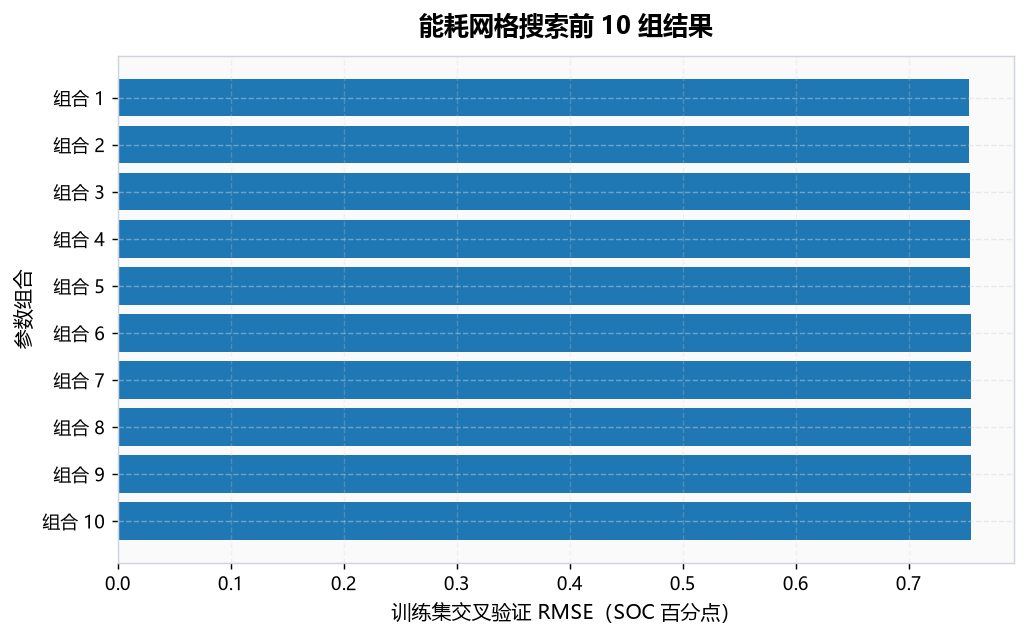

In [105]:
energy_grid_results = pd.DataFrame(
    energy_grid_search.cv_results_
)

energy_grid_results["CV_RMSE"] = (
    -energy_grid_results["mean_test_score"]
)

energy_grid_top10 = (
    energy_grid_results
    .sort_values("rank_test_score")
    .head(10)
    .copy()
)

energy_grid_top10["组合"] = [
    f"组合 {index}"
    for index in range(1, len(energy_grid_top10) + 1)
]

display(
    energy_grid_top10[
        ["组合", "CV_RMSE", "std_test_score", "params"]
    ].round(4)
)

plt.figure(figsize=(8, 5))
plt.barh(
    energy_grid_top10["组合"][::-1],
    energy_grid_top10["CV_RMSE"][::-1],
)
plt.xlabel("训练集交叉验证 RMSE（SOC 百分点）")
plt.ylabel("参数组合")
plt.title("能耗网格搜索前 10 组结果", fontsize=14, pad=12)
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## 9.6 使用两个最优 XGBoost 模型预测测试集

**本单元功能**

- 使用网格搜索得到的最佳时间模型和最佳能耗模型；
- 预测测试集；
- 计算最终测试集 MAE、RMSE 和 R²。

这里的 XGBoost 指标均来自网格搜索后的最优模型。

In [106]:
xgb_time_pred = xgb_time_model.predict(X_test)
xgb_energy_pred = xgb_energy_model.predict(X_test)

xgb_time_metrics = get_metrics(
    y_time_test,
    xgb_time_pred,
)

xgb_energy_metrics = get_metrics(
    y_energy_test,
    xgb_energy_pred,
)

print("网格搜索后的任务时间 XGBoost：")
display(pd.DataFrame(
    [xgb_time_metrics],
    index=["XGBoost（网格搜索）"],
).round(4))

print("网格搜索后的能耗 XGBoost：")
display(pd.DataFrame(
    [xgb_energy_metrics],
    index=["XGBoost（网格搜索）"],
).round(4))

网格搜索后的任务时间 XGBoost：


,MAE,RMSE,R2
XGBoost（网格搜索）,24.739,35.8623,0.966


网格搜索后的能耗 XGBoost：


,MAE,RMSE,R2
XGBoost（网格搜索）,0.5687,0.7383,0.9178


## 9.7 绘制最优 XGBoost 的预测结果

**本单元功能**

- 绘制时间模型的真实值—预测值图和残差图；
- 绘制能耗模型的真实值—预测值图和残差图。

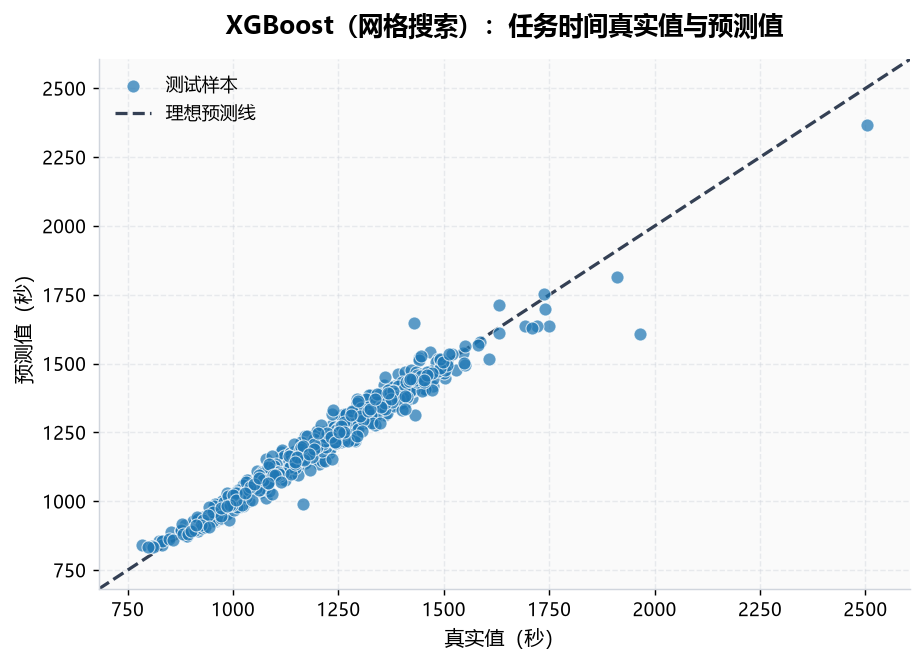

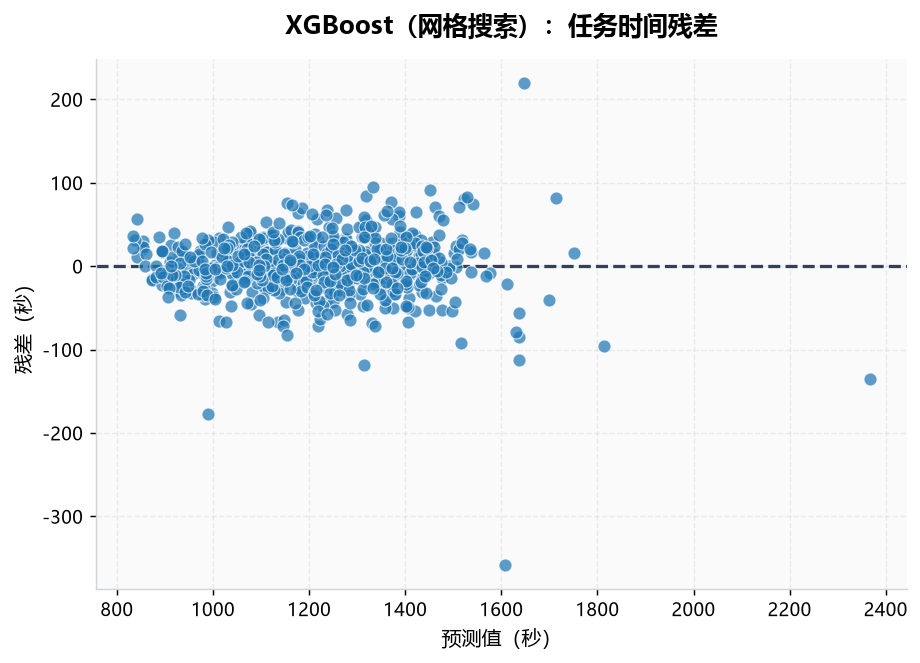

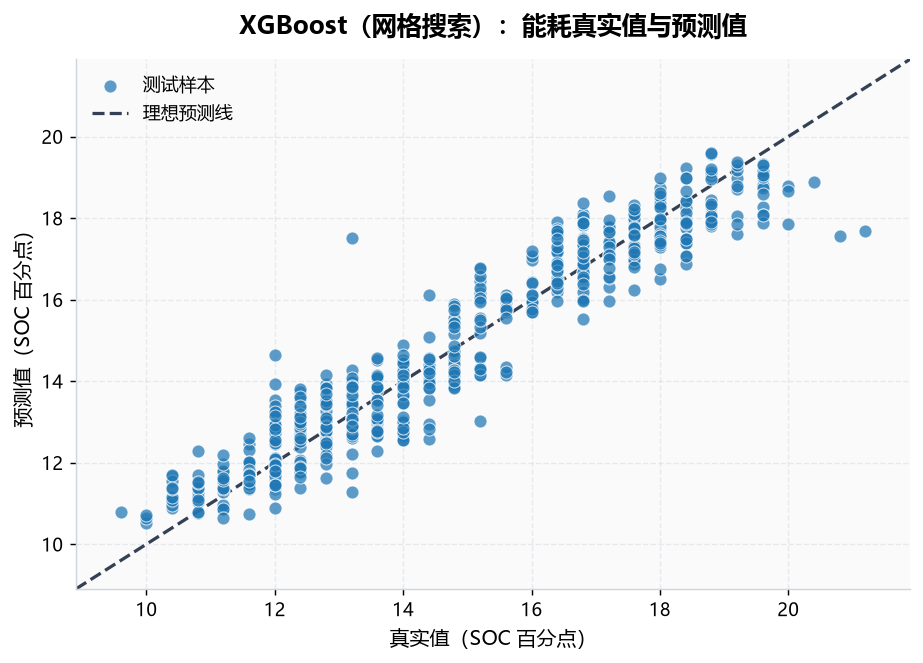

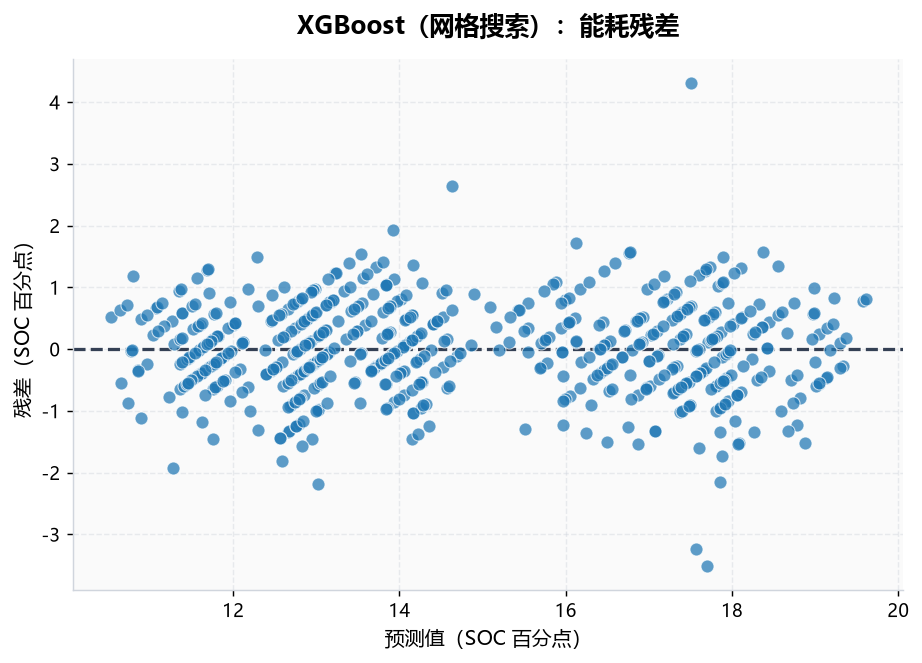

In [107]:
plot_actual_vs_predicted(
    y_time_test,
    xgb_time_pred,
    "XGBoost（网格搜索）：任务时间真实值与预测值",
    "秒",
    color=MODEL_COLORS["XGBoost"],
)
plot_residuals(
    y_time_test,
    xgb_time_pred,
    "XGBoost（网格搜索）：任务时间残差",
    "秒",
    color=MODEL_COLORS["XGBoost"],
)

plot_actual_vs_predicted(
    y_energy_test,
    xgb_energy_pred,
    "XGBoost（网格搜索）：能耗真实值与预测值",
    "SOC 百分点",
    color=MODEL_COLORS["XGBoost"],
)
plot_residuals(
    y_energy_test,
    xgb_energy_pred,
    "XGBoost（网格搜索）：能耗残差",
    "SOC 百分点",
    color=MODEL_COLORS["XGBoost"],
)

## 9.8 查看最优 XGBoost 的特征重要性

**本单元功能**

- 分别读取最终时间模型和能耗模型的特征重要性；
- 绘制横向条形图；
- 输出按重要性降序排列的表格。

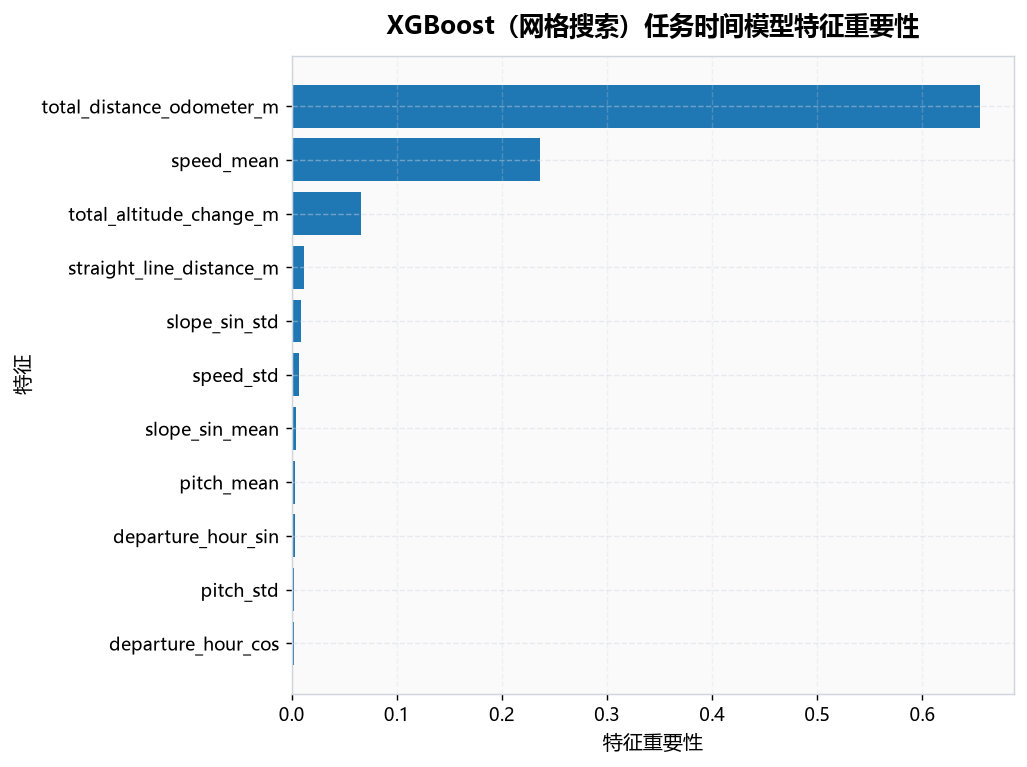

,feature,importance
2,total_distance_odometer_m,0.6543
6,speed_mean,0.2362
3,total_altitude_change_m,0.0659
10,straight_line_distance_m,0.0120
9,slope_sin_std,0.0090
7,speed_std,0.0074
8,slope_sin_mean,0.0041
4,pitch_mean,0.0035
0,departure_hour_sin,0.0027
5,pitch_std,0.0025


In [108]:
time_importance = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": xgb_time_model.feature_importances_,
}).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(
    time_importance["feature"],
    time_importance["importance"],
)
plt.xlabel("特征重要性")
plt.ylabel("特征")
plt.title(
    "XGBoost（网格搜索）任务时间模型特征重要性",
    fontsize=14,
    pad=12,
)
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

display(
    time_importance
    .sort_values("importance", ascending=False)
    .round(4)
)

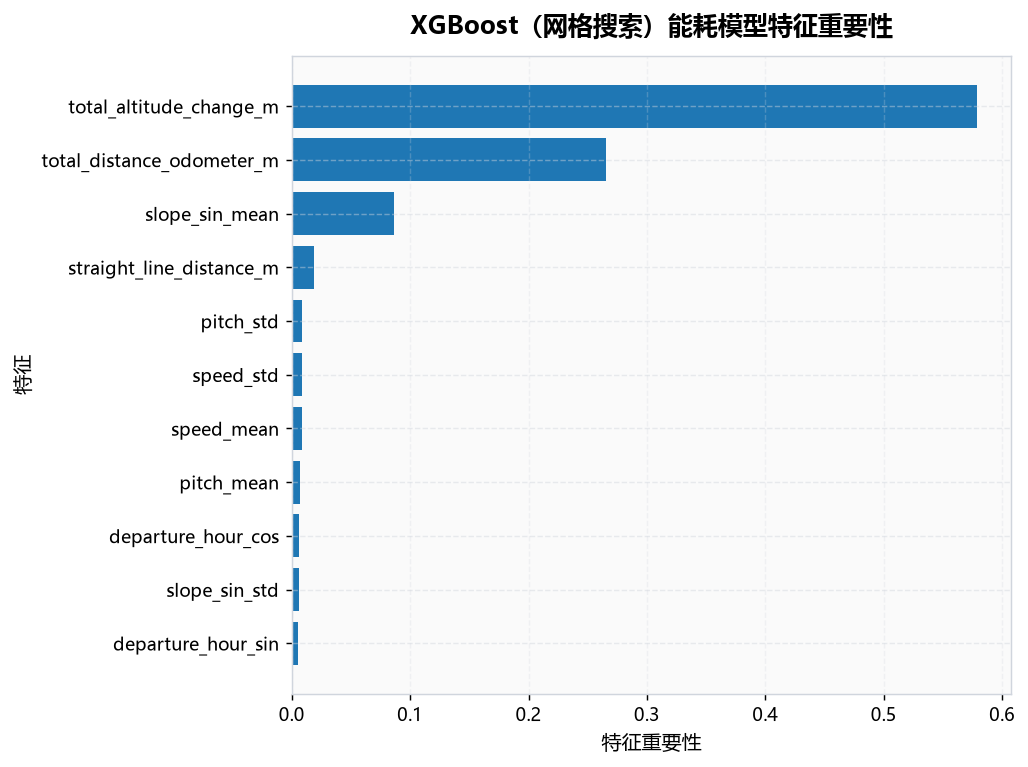

,feature,importance
3,total_altitude_change_m,0.5789
2,total_distance_odometer_m,0.2656
8,slope_sin_mean,0.0868
10,straight_line_distance_m,0.0190
5,pitch_std,0.0090
7,speed_std,0.0086
6,speed_mean,0.0085
4,pitch_mean,0.0068
1,departure_hour_cos,0.0061
9,slope_sin_std,0.0058


In [109]:
energy_importance = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": xgb_energy_model.feature_importances_,
}).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(
    energy_importance["feature"],
    energy_importance["importance"],
)
plt.xlabel("特征重要性")
plt.ylabel("特征")
plt.title(
    "XGBoost（网格搜索）能耗模型特征重要性",
    fontsize=14,
    pad=12,
)
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

display(
    energy_importance
    .sort_values("importance", ascending=False)
    .round(4)
)

# 10. LightGBM：网格搜索后训练最优模型

LightGBM 使用与 XGBoost 相同的训练集、测试集和交叉验证划分。

**本节流程**

1. 定义 LightGBM 参数网格；
2. 分别搜索任务时间和能耗模型的最优参数；
3. 使用 `best_estimator_` 在测试集上预测；
4. 计算指标、绘图并查看特征重要性。

> 首次运行前若缺少依赖，请执行：`pip install lightgbm`。

## 10.1 定义 LightGBM 参数网格

**输入**：训练集和前面创建的 `search_cv`。

**输出**：LightGBM 候选参数组合。

In [110]:
lgbm_param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.03, 0.05, 0.10],
    "num_leaves": [7, 15, 31],
    "min_child_samples": [10, 20],
    "colsample_bytree": [0.80, 0.90, 1.00],
}

lgbm_grid_size = int(np.prod([
    len(values)
    for values in lgbm_param_grid.values()
]))

print(f"LightGBM 参数组合数：{lgbm_grid_size}")
print(
    "每个目标需要拟合："
    f"{lgbm_grid_size * search_cv_folds} 次"
)


LightGBM 参数组合数：216
每个目标需要拟合：1080 次


## 10.2 搜索任务时间模型

**输入**：`X_train`、`y_time_train`。

**输出**：任务时间最优 LightGBM 模型和完整搜索结果。

In [111]:
lgbm_time_grid_search = GridSearchCV(
    estimator=LGBMRegressor(
        objective="regression",
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbosity=-1,
    ),
    param_grid=lgbm_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=search_cv,
    n_jobs=GRID_SEARCH_N_JOBS,
    verbose=1,
    return_train_score=True,
    refit=True,
)

lgbm_time_grid_search.fit(X_train, y_time_train)
lgbm_time_model = lgbm_time_grid_search.best_estimator_

lgbm_time_grid_results = pd.DataFrame(
    lgbm_time_grid_search.cv_results_
)
lgbm_time_grid_results["CV_RMSE"] = (
    -lgbm_time_grid_results["mean_test_score"]
)

print("LightGBM 任务时间最优参数：")
display(pd.DataFrame(
    list(lgbm_time_grid_search.best_params_.items()),
    columns=["parameter", "best_value"],
))
print(
    "LightGBM 任务时间最优训练集 CV RMSE："
    f"{-lgbm_time_grid_search.best_score_:.4f} 秒"
)


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
LightGBM 任务时间最优参数：


,parameter,best_value
0,colsample_bytree,0.8
1,learning_rate,0.1
2,min_child_samples,10.0
3,n_estimators,300.0
4,num_leaves,15.0


LightGBM 任务时间最优训练集 CV RMSE：38.3914 秒


## 10.3 搜索能耗模型

**输入**：`X_train`、`y_energy_train`。

**输出**：能耗最优 LightGBM 模型和完整搜索结果。

In [112]:
lgbm_energy_grid_search = GridSearchCV(
    estimator=LGBMRegressor(
        objective="regression",
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbosity=-1,
    ),
    param_grid=lgbm_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=search_cv,
    n_jobs=GRID_SEARCH_N_JOBS,
    verbose=1,
    return_train_score=True,
    refit=True,
)

lgbm_energy_grid_search.fit(X_train, y_energy_train)
lgbm_energy_model = lgbm_energy_grid_search.best_estimator_

lgbm_energy_grid_results = pd.DataFrame(
    lgbm_energy_grid_search.cv_results_
)
lgbm_energy_grid_results["CV_RMSE"] = (
    -lgbm_energy_grid_results["mean_test_score"]
)

print("LightGBM 能耗最优参数：")
display(pd.DataFrame(
    list(lgbm_energy_grid_search.best_params_.items()),
    columns=["parameter", "best_value"],
))
print(
    "LightGBM 能耗最优训练集 CV RMSE："
    f"{-lgbm_energy_grid_search.best_score_:.4f} SOC 百分点"
)


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
LightGBM 能耗最优参数：


,parameter,best_value
0,colsample_bytree,0.80
1,learning_rate,0.03
2,min_child_samples,10.00
3,n_estimators,200.00
4,num_leaves,31.00


LightGBM 能耗最优训练集 CV RMSE：0.7467 SOC 百分点


## 10.4 使用最优 LightGBM 模型预测测试集

**输入**：两个 `best_estimator_` 和 `X_test`。

**输出**：测试集预测值以及 MAE、RMSE、R²。

In [113]:
lgbm_time_pred = lgbm_time_model.predict(X_test)
lgbm_energy_pred = lgbm_energy_model.predict(X_test)

lgbm_time_metrics = get_metrics(
    y_time_test,
    lgbm_time_pred,
)
lgbm_energy_metrics = get_metrics(
    y_energy_test,
    lgbm_energy_pred,
)

print("LightGBM 任务时间测试集指标：")
display(pd.DataFrame(
    [lgbm_time_metrics],
    index=["LightGBM（网格搜索）"],
).round(4))

print("LightGBM 能耗测试集指标：")
display(pd.DataFrame(
    [lgbm_energy_metrics],
    index=["LightGBM（网格搜索）"],
).round(4))


LightGBM 任务时间测试集指标：


,MAE,RMSE,R2
LightGBM（网格搜索）,26.253,37.6169,0.9625


LightGBM 能耗测试集指标：


,MAE,RMSE,R2
LightGBM（网格搜索）,0.5618,0.7332,0.9189


## 10.5 绘制 LightGBM 预测结果

检查预测点是否接近理想对角线，并观察残差是否围绕 0 分布。

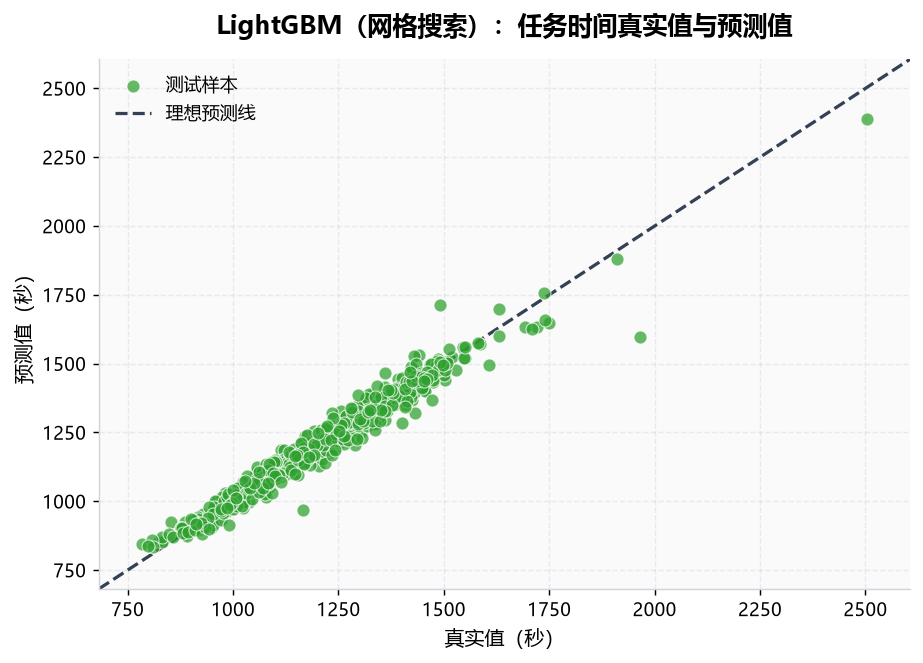

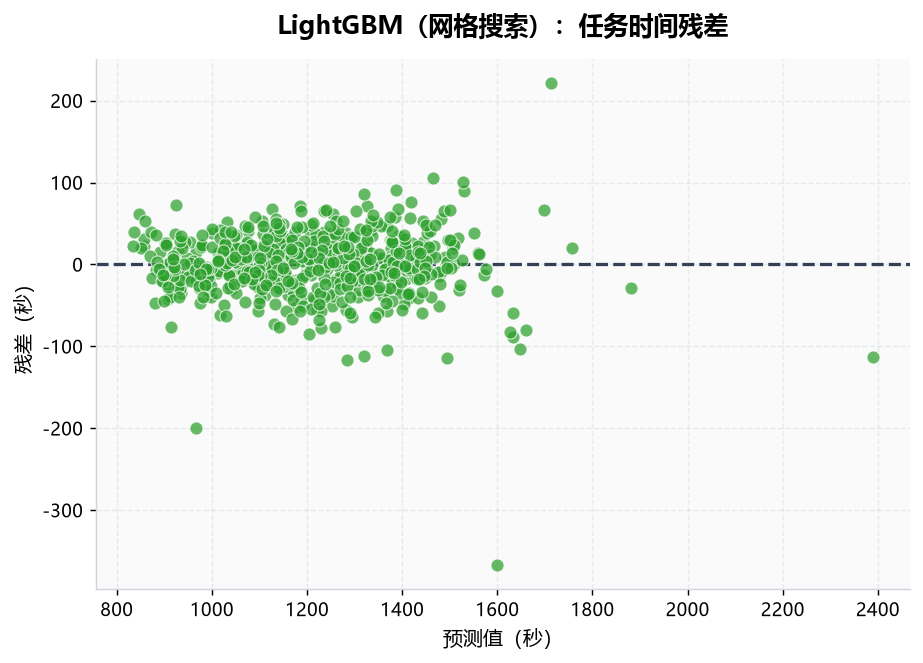

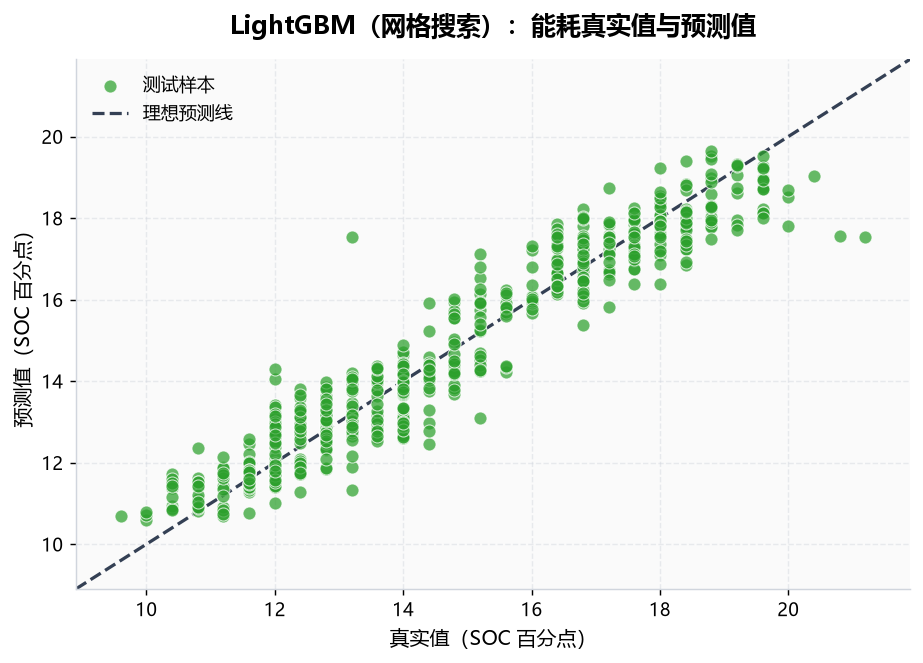

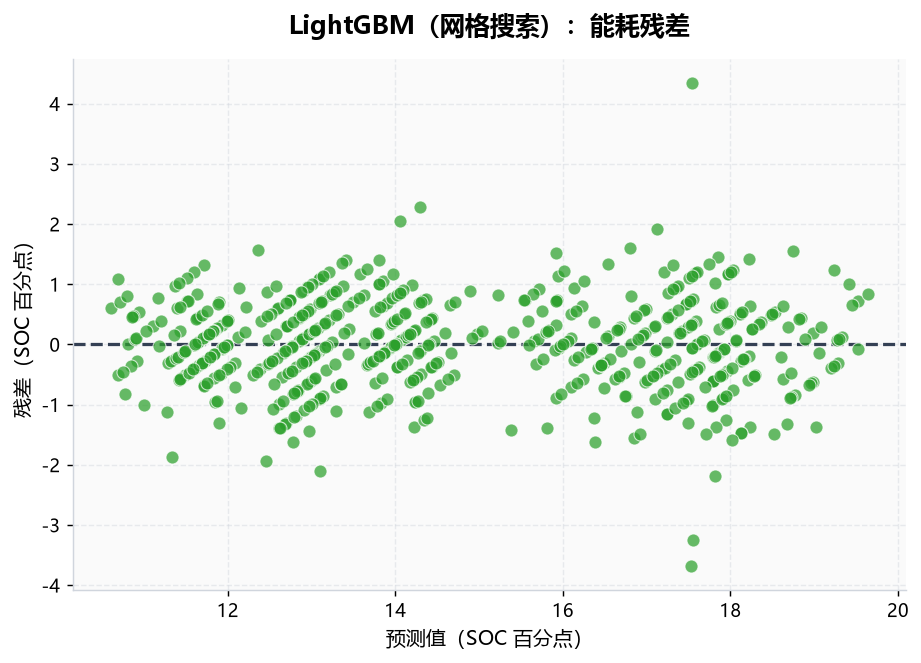

In [114]:
plot_actual_vs_predicted(
    y_time_test,
    lgbm_time_pred,
    "LightGBM（网格搜索）：任务时间真实值与预测值",
    "秒",
    color=MODEL_COLORS["LightGBM"],
)
plot_residuals(
    y_time_test,
    lgbm_time_pred,
    "LightGBM（网格搜索）：任务时间残差",
    "秒",
    color=MODEL_COLORS["LightGBM"],
)

plot_actual_vs_predicted(
    y_energy_test,
    lgbm_energy_pred,
    "LightGBM（网格搜索）：能耗真实值与预测值",
    "SOC 百分点",
    color=MODEL_COLORS["LightGBM"],
)
plot_residuals(
    y_energy_test,
    lgbm_energy_pred,
    "LightGBM（网格搜索）：能耗残差",
    "SOC 百分点",
    color=MODEL_COLORS["LightGBM"],
)


## 10.6 查看 LightGBM 特征重要性

分别显示任务时间模型和能耗模型的内置特征重要性。

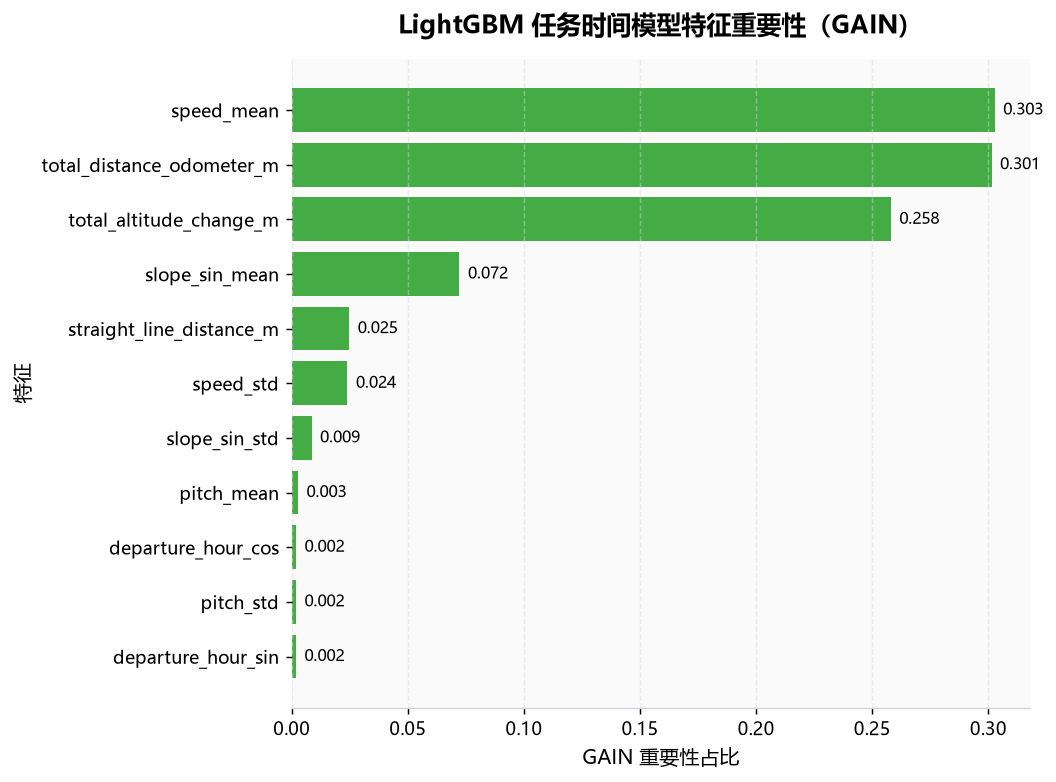

,feature,importance,gain
6,speed_mean,0.3027,1.588473e+08
2,total_distance_odometer_m,0.3014,1.581279e+08
3,total_altitude_change_m,0.2580,1.353784e+08
8,slope_sin_mean,0.0723,3.791048e+07
10,straight_line_distance_m,0.0248,1.300331e+07
7,speed_std,0.0240,1.259931e+07
9,slope_sin_std,0.0085,4.482265e+06
4,pitch_mean,0.0027,1.428896e+06
1,departure_hour_cos,0.0019,9.820722e+05
5,pitch_std,0.0019,9.775589e+05


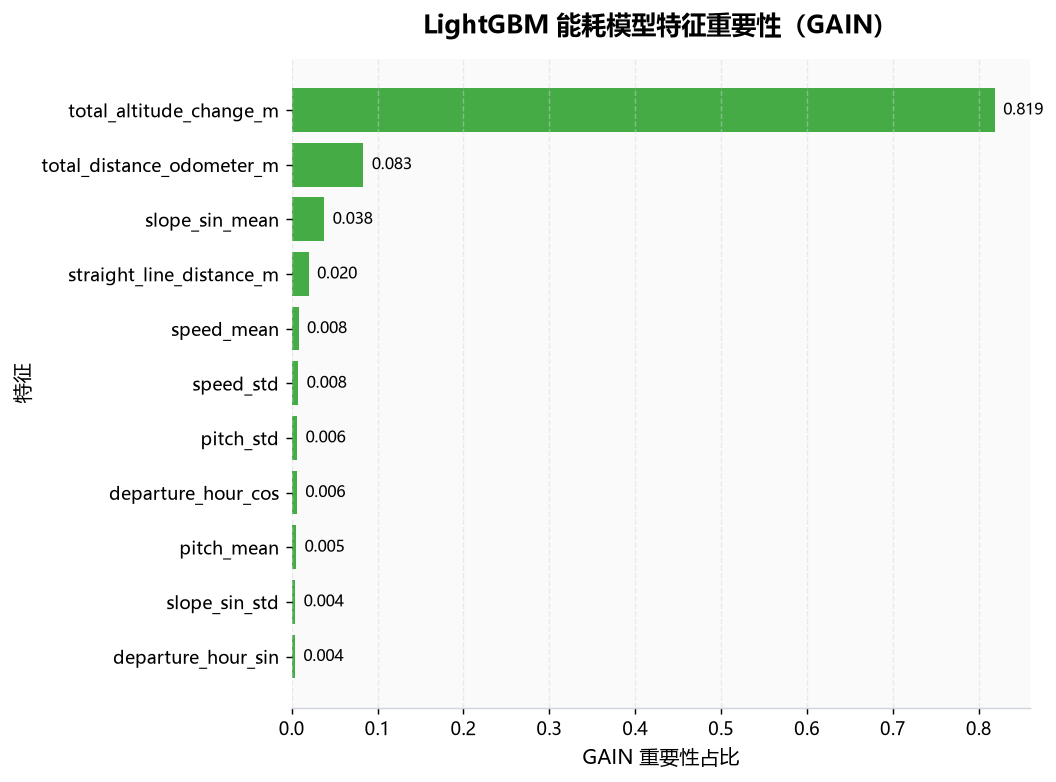

,feature,importance,gain
3,total_altitude_change_m,0.8185,226719.3308
2,total_distance_odometer_m,0.0834,23099.8241
8,slope_sin_mean,0.0378,10478.2495
10,straight_line_distance_m,0.0197,5456.0171
6,speed_mean,0.0079,2198.6266
7,speed_std,0.0075,2088.8674
5,pitch_std,0.0063,1735.9133
1,departure_hour_cos,0.0060,1649.4115
4,pitch_mean,0.0051,1415.7920
9,slope_sin_std,0.0040,1116.0900


In [115]:
def get_lgbm_gain_importance(model, feature_names):
    """读取 LightGBM 的 GAIN 重要性，并归一化为占比。"""
    gain = model.booster_.feature_importance(
        importance_type="gain"
    ).astype(float)

    gain_sum = gain.sum()
    gain_ratio = gain / gain_sum if gain_sum > 0 else gain

    return pd.DataFrame({
        "feature": feature_names,
        "importance": gain_ratio,
        "gain": gain,
    }).sort_values("importance", ascending=False)


lgbm_time_importance = get_lgbm_gain_importance(
    lgbm_time_model,
    FEATURE_COLS,
)
plot_feature_importance(
    lgbm_time_importance,
    "LightGBM 任务时间模型特征重要性（GAIN）",
    xlabel="GAIN 重要性占比",
    color=MODEL_COLORS["LightGBM"],
)
display(lgbm_time_importance.round(4))


lgbm_energy_importance = get_lgbm_gain_importance(
    lgbm_energy_model,
    FEATURE_COLS,
)
plot_feature_importance(
    lgbm_energy_importance,
    "LightGBM 能耗模型特征重要性（GAIN）",
    xlabel="GAIN 重要性占比",
    color=MODEL_COLORS["LightGBM"],
)
display(lgbm_energy_importance.round(4))


# 11. HGBR：网格搜索后训练最优模型

HGBR 指 scikit-learn 的 `HistGradientBoostingRegressor`。

**本节流程**

1. 定义 HGBR 参数网格；
2. 分别搜索任务时间和能耗模型；
3. 使用最优模型预测测试集；
4. 计算指标并绘制预测图和残差图。

HGBR 没有内置的 `feature_importances_` 属性，因此本节不绘制内置特征重要性。

## 11.1 定义 HGBR 参数网格

**输入**：训练集和前面创建的 `search_cv`。

**输出**：HGBR 候选参数组合。

In [116]:
hgbr_param_grid = {
    "max_iter": [100, 200, 300],
    "learning_rate": [0.01, 0.03, 0.05, 0.10],
    "max_leaf_nodes": [7, 15, 31],
    "min_samples_leaf": [10, 20],
    "l2_regularization": [0.1, 0.5, 1.0],
}

hgbr_grid_size = int(np.prod([
    len(values)
    for values in hgbr_param_grid.values()
]))

print(f"HGBR 参数组合数：{hgbr_grid_size}")
print(
    "每个目标需要拟合："
    f"{hgbr_grid_size * search_cv_folds} 次"
)


HGBR 参数组合数：216
每个目标需要拟合：1080 次


## 11.2 搜索任务时间模型

**输入**：`X_train`、`y_time_train`。

**输出**：任务时间最优 HGBR 模型和完整搜索结果。

In [117]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

hgbr_time_grid_search = GridSearchCV(
    estimator=HistGradientBoostingRegressor(
        loss="squared_error",
        early_stopping=False,
        random_state=RANDOM_STATE,
    ),
    param_grid=hgbr_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=search_cv,
    n_jobs=4,
    verbose=1,
    return_train_score=True,
    refit=True,
)

hgbr_time_grid_search.fit(X_train, y_time_train)
hgbr_time_model = hgbr_time_grid_search.best_estimator_

hgbr_time_grid_results = pd.DataFrame(
    hgbr_time_grid_search.cv_results_
)

hgbr_time_grid_results["CV_RMSE"] = (
    -hgbr_time_grid_results["mean_test_score"]
)

print("HGBR 任务时间最优参数：")
display(
    pd.DataFrame(
        list(hgbr_time_grid_search.best_params_.items()),
        columns=["parameter", "best_value"],
    )
)

print(
    "HGBR 任务时间最优训练集 CV RMSE："
    f"{-hgbr_time_grid_search.best_score_:.4f} 秒"
)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
HGBR 任务时间最优参数：


,parameter,best_value
0,l2_regularization,0.5
1,learning_rate,0.1
2,max_iter,300.0
3,max_leaf_nodes,15.0
4,min_samples_leaf,10.0


HGBR 任务时间最优训练集 CV RMSE：38.8733 秒


## 11.3 搜索能耗模型

**输入**：`X_train`、`y_energy_train`。

**输出**：能耗最优 HGBR 模型和完整搜索结果。

In [118]:
hgbr_energy_grid_search = GridSearchCV(
    estimator=HistGradientBoostingRegressor(
        loss="squared_error",
        early_stopping=False,
        random_state=RANDOM_STATE,
    ),
    param_grid=hgbr_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=search_cv,
    n_jobs=GRID_SEARCH_N_JOBS,
    verbose=1,
    return_train_score=True,
    refit=True,
)

hgbr_energy_grid_search.fit(X_train, y_energy_train)
hgbr_energy_model = hgbr_energy_grid_search.best_estimator_

hgbr_energy_grid_results = pd.DataFrame(
    hgbr_energy_grid_search.cv_results_
)
hgbr_energy_grid_results["CV_RMSE"] = (
    -hgbr_energy_grid_results["mean_test_score"]
)

print("HGBR 能耗最优参数：")
display(pd.DataFrame(
    list(hgbr_energy_grid_search.best_params_.items()),
    columns=["parameter", "best_value"],
))
print(
    "HGBR 能耗最优训练集 CV RMSE："
    f"{-hgbr_energy_grid_search.best_score_:.4f} SOC 百分点"
)


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
HGBR 能耗最优参数：


,parameter,best_value
0,l2_regularization,0.10
1,learning_rate,0.05
2,max_iter,100.00
3,max_leaf_nodes,31.00
4,min_samples_leaf,10.00


HGBR 能耗最优训练集 CV RMSE：0.7492 SOC 百分点


## 11.4 使用最优 HGBR 模型预测测试集

**输入**：两个 `best_estimator_` 和 `X_test`。

**输出**：测试集预测值以及 MAE、RMSE、R²。

In [119]:
hgbr_time_pred = hgbr_time_model.predict(X_test)
hgbr_energy_pred = hgbr_energy_model.predict(X_test)

hgbr_time_metrics = get_metrics(
    y_time_test,
    hgbr_time_pred,
)
hgbr_energy_metrics = get_metrics(
    y_energy_test,
    hgbr_energy_pred,
)

print("HGBR 任务时间测试集指标：")
display(pd.DataFrame(
    [hgbr_time_metrics],
    index=["HGBR（网格搜索）"],
).round(4))

print("HGBR 能耗测试集指标：")
display(pd.DataFrame(
    [hgbr_energy_metrics],
    index=["HGBR（网格搜索）"],
).round(4))


HGBR 任务时间测试集指标：


,MAE,RMSE,R2
HGBR（网格搜索）,25.5244,36.808,0.9641


HGBR 能耗测试集指标：


,MAE,RMSE,R2
HGBR（网格搜索）,0.5674,0.7379,0.9179


## 11.5 绘制 HGBR 预测结果

检查预测点是否接近理想对角线，并观察残差是否围绕 0 分布。

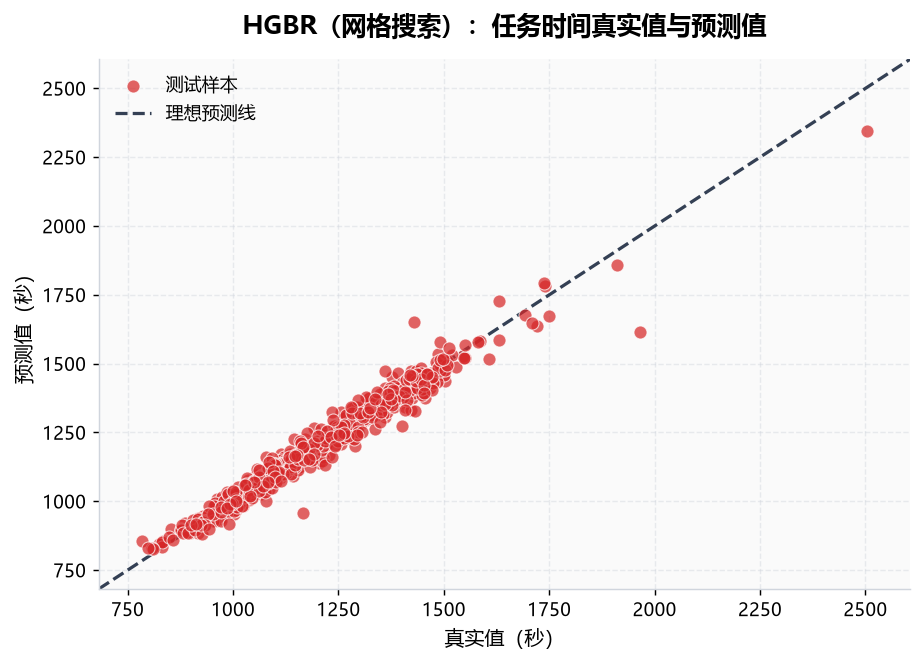

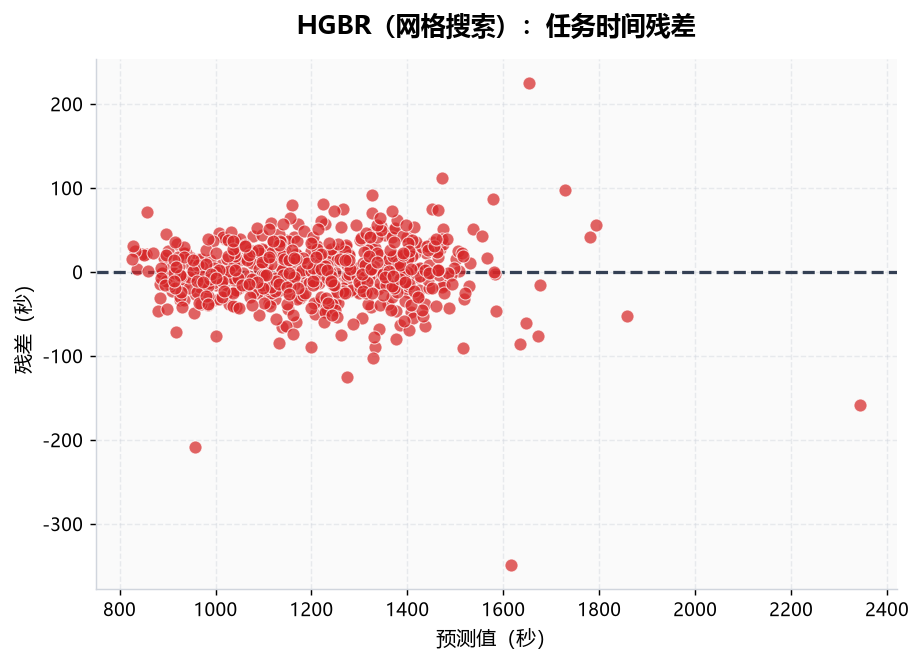

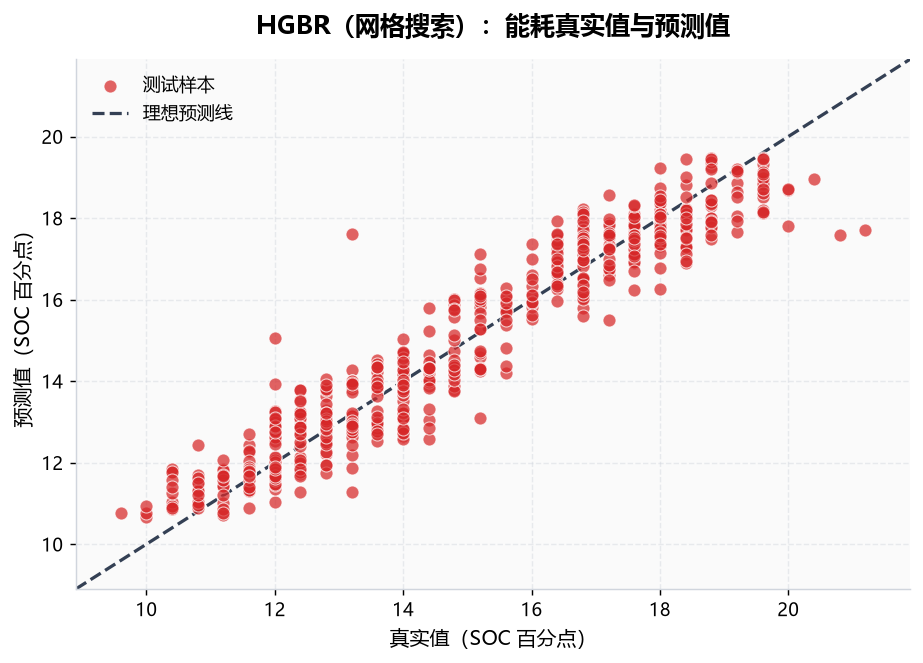

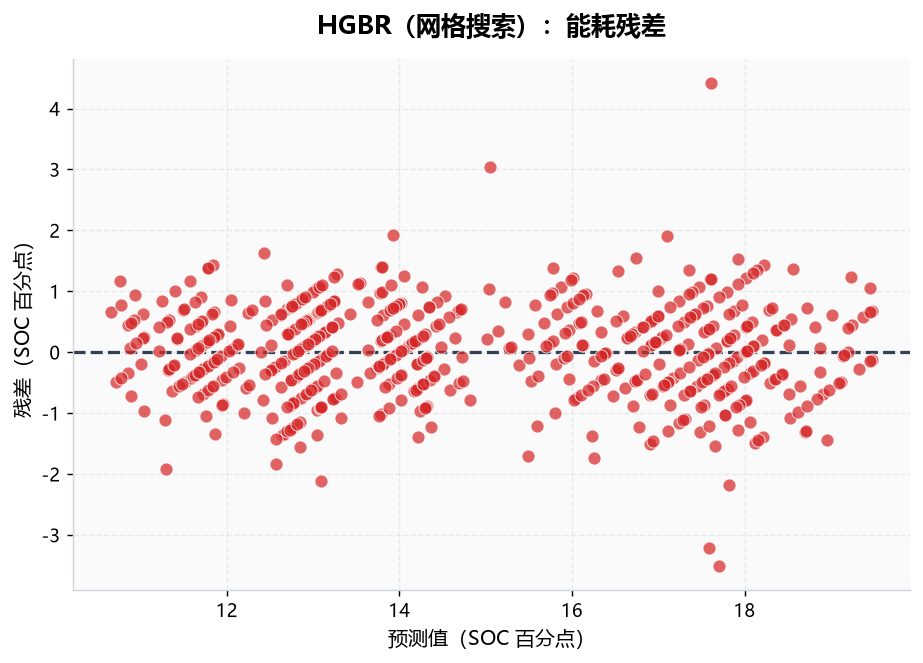

In [120]:
plot_actual_vs_predicted(
    y_time_test,
    hgbr_time_pred,
    "HGBR（网格搜索）：任务时间真实值与预测值",
    "秒",
    color=MODEL_COLORS["HGBR"],
)
plot_residuals(
    y_time_test,
    hgbr_time_pred,
    "HGBR（网格搜索）：任务时间残差",
    "秒",
    color=MODEL_COLORS["HGBR"],
)

plot_actual_vs_predicted(
    y_energy_test,
    hgbr_energy_pred,
    "HGBR（网格搜索）：能耗真实值与预测值",
    "SOC 百分点",
    color=MODEL_COLORS["HGBR"],
)
plot_residuals(
    y_energy_test,
    hgbr_energy_pred,
    "HGBR（网格搜索）：能耗残差",
    "SOC 百分点",
    color=MODEL_COLORS["HGBR"],
)


# 12. 测试集模型统一比较

**本单元功能**

统一比较以下五类模型：

- 里程比例 Baseline；
- 线性回归；
- XGBoost（网格搜索）；
- LightGBM（网格搜索）；
- HGBR（网格搜索）。

## 随机森林回归

使用网格搜索分别训练任务时间和能耗随机森林模型，并纳入测试集、交叉验证和模型保存结果。


In [121]:
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 8, 16],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.8],
}

rf_grid_size = int(np.prod([
    len(values)
    for values in rf_param_grid.values()
]))

print(f"随机森林参数组合数：{rf_grid_size}")
print(
    "每个目标需要拟合："
    f"{rf_grid_size * search_cv_folds} 次"
)


随机森林参数组合数：108
每个目标需要拟合：540 次


In [122]:
rf_time_grid_search = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    param_grid=rf_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=search_cv,
    n_jobs=GRID_SEARCH_N_JOBS,
    verbose=1,
    return_train_score=True,
    refit=True,
)

rf_time_grid_search.fit(X_train, y_time_train)
rf_time_model = rf_time_grid_search.best_estimator_
rf_time_grid_results = pd.DataFrame(
    rf_time_grid_search.cv_results_
)
rf_time_grid_results["CV_RMSE"] = (
    -rf_time_grid_results["mean_test_score"]
)

print("随机森林任务时间最优参数：")
display(pd.DataFrame(
    list(rf_time_grid_search.best_params_.items()),
    columns=["parameter", "best_value"],
))
print(
    "随机森林任务时间最优训练集 CV RMSE："
    f"{-rf_time_grid_search.best_score_:.4f} 秒"
)


rf_energy_grid_search = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    param_grid=rf_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=search_cv,
    n_jobs=GRID_SEARCH_N_JOBS,
    verbose=1,
    return_train_score=True,
    refit=True,
)

rf_energy_grid_search.fit(X_train, y_energy_train)
rf_energy_model = rf_energy_grid_search.best_estimator_
rf_energy_grid_results = pd.DataFrame(
    rf_energy_grid_search.cv_results_
)
rf_energy_grid_results["CV_RMSE"] = (
    -rf_energy_grid_results["mean_test_score"]
)

print("随机森林能耗最优参数：")
display(pd.DataFrame(
    list(rf_energy_grid_search.best_params_.items()),
    columns=["parameter", "best_value"],
))
print(
    "随机森林能耗最优训练集 CV RMSE："
    f"{-rf_energy_grid_search.best_score_:.4f} SOC 百分点"
)


Fitting 5 folds for each of 108 candidates, totalling 540 fits
随机森林任务时间最优参数：


,parameter,best_value
0,max_depth,NaN
1,max_features,0.8
2,min_samples_leaf,1.0
3,min_samples_split,2.0
4,n_estimators,300.0


随机森林任务时间最优训练集 CV RMSE：40.9369 秒
Fitting 5 folds for each of 108 candidates, totalling 540 fits
随机森林能耗最优参数：


,parameter,best_value
0,max_depth,NaN
1,max_features,0.8
2,min_samples_leaf,1.0
3,min_samples_split,2.0
4,n_estimators,300.0


随机森林能耗最优训练集 CV RMSE：0.7451 SOC 百分点


随机森林任务时间测试集指标：


,MAE,RMSE,R2
随机森林（网格搜索）,26.3014,39.508,0.9587


随机森林能耗测试集指标：


,MAE,RMSE,R2
随机森林（网格搜索）,0.5634,0.7308,0.9194


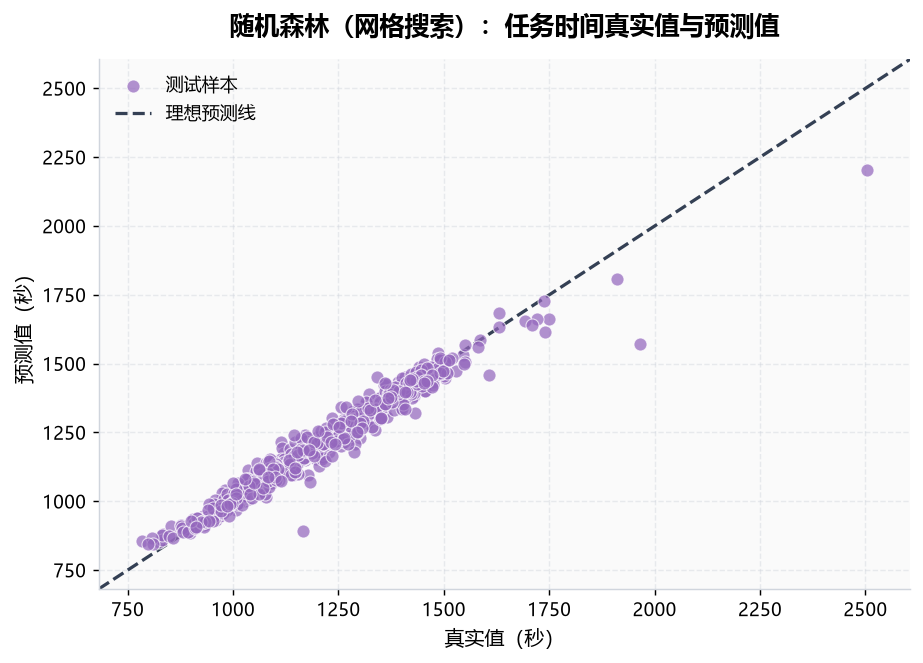

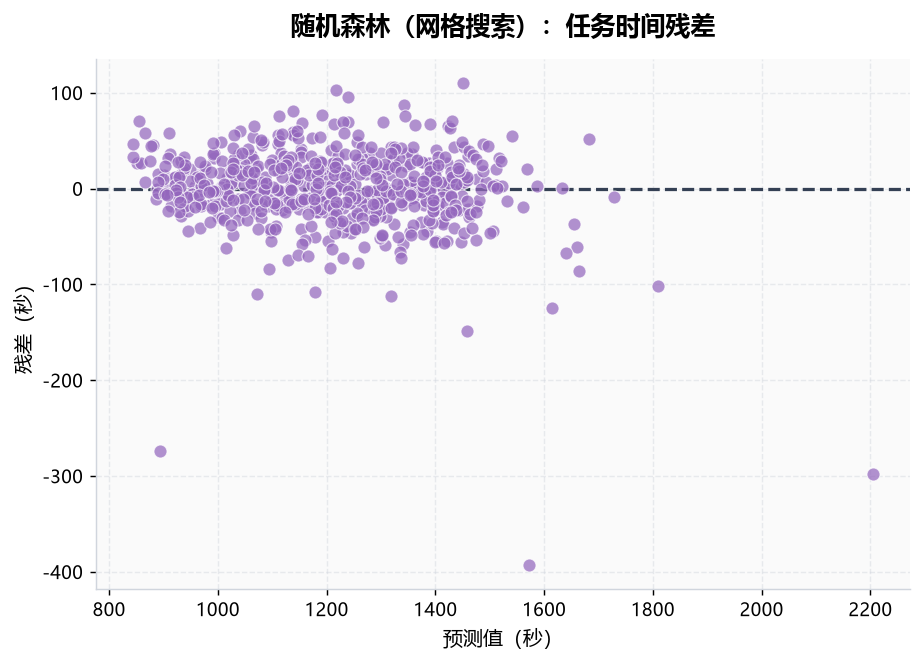

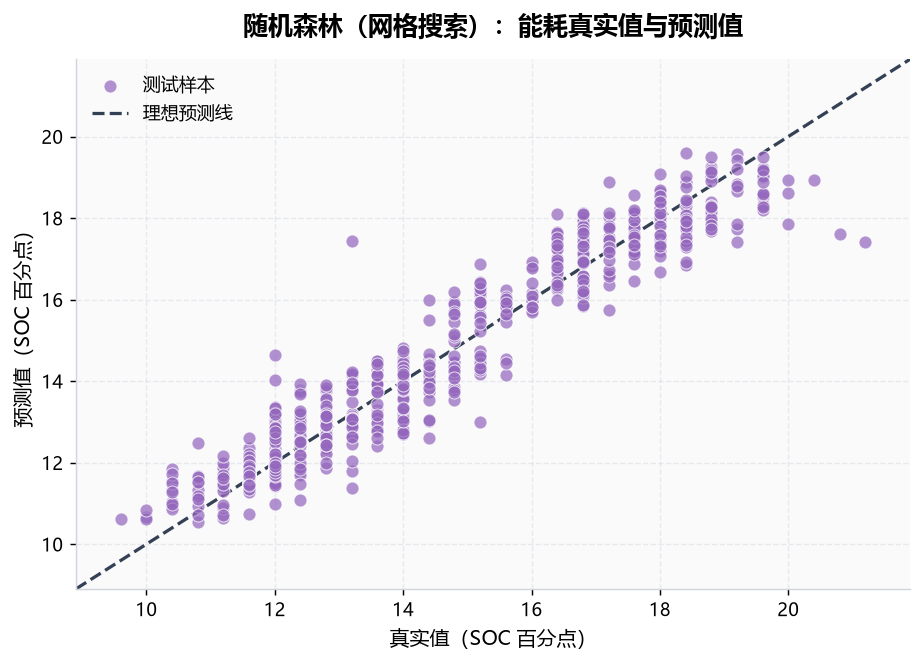

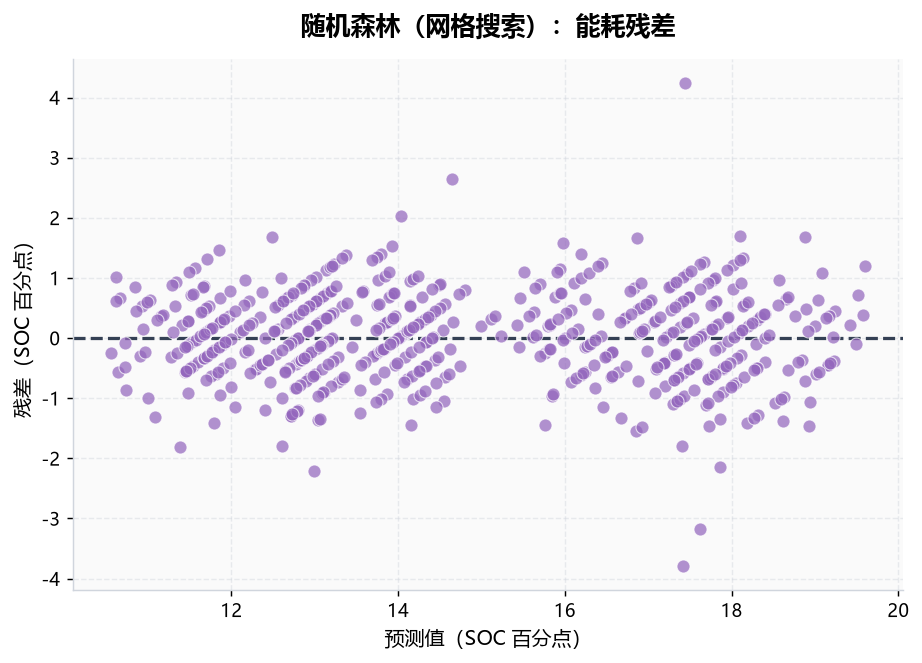

In [123]:
rf_time_pred = rf_time_model.predict(X_test)
rf_energy_pred = rf_energy_model.predict(X_test)

rf_time_metrics = get_metrics(y_time_test, rf_time_pred)
rf_energy_metrics = get_metrics(y_energy_test, rf_energy_pred)

print("随机森林任务时间测试集指标：")
display(pd.DataFrame(
    [rf_time_metrics],
    index=["随机森林（网格搜索）"],
).round(4))

print("随机森林能耗测试集指标：")
display(pd.DataFrame(
    [rf_energy_metrics],
    index=["随机森林（网格搜索）"],
).round(4))

plot_actual_vs_predicted(
    y_time_test,
    rf_time_pred,
    "随机森林（网格搜索）：任务时间真实值与预测值",
    "秒",
    color=MODEL_COLORS["随机森林"],
)
plot_residuals(
    y_time_test,
    rf_time_pred,
    "随机森林（网格搜索）：任务时间残差",
    "秒",
    color=MODEL_COLORS["随机森林"],
)

plot_actual_vs_predicted(
    y_energy_test,
    rf_energy_pred,
    "随机森林（网格搜索）：能耗真实值与预测值",
    "SOC 百分点",
    color=MODEL_COLORS["随机森林"],
)
plot_residuals(
    y_energy_test,
    rf_energy_pred,
    "随机森林（网格搜索）：能耗残差",
    "SOC 百分点",
    color=MODEL_COLORS["随机森林"],
)


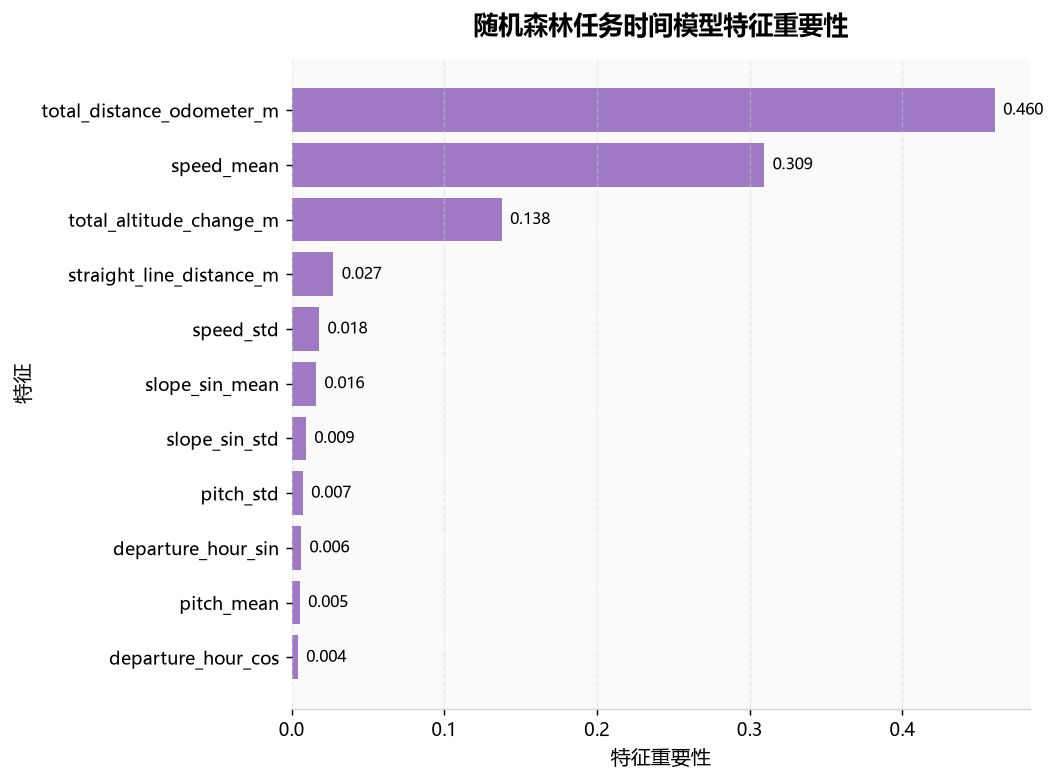

,feature,importance
2,total_distance_odometer_m,0.4604
6,speed_mean,0.3094
3,total_altitude_change_m,0.1375
10,straight_line_distance_m,0.0272
7,speed_std,0.0179
8,slope_sin_mean,0.0159
9,slope_sin_std,0.0092
5,pitch_std,0.0072
0,departure_hour_sin,0.0061
4,pitch_mean,0.0052


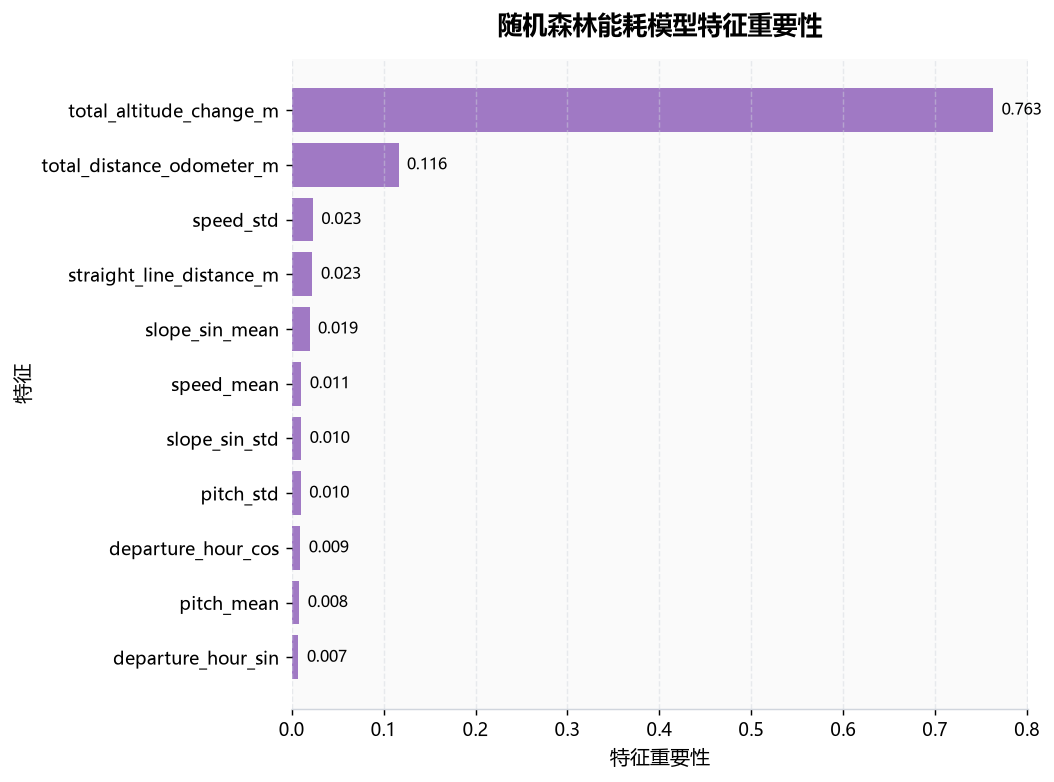

,feature,importance
3,total_altitude_change_m,0.7630
2,total_distance_odometer_m,0.1162
7,speed_std,0.0230
10,straight_line_distance_m,0.0226
8,slope_sin_mean,0.0194
6,speed_mean,0.0105
9,slope_sin_std,0.0104
5,pitch_std,0.0099
1,departure_hour_cos,0.0094
4,pitch_mean,0.0083


In [124]:
rf_time_importance = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": rf_time_model.feature_importances_,
}).sort_values("importance", ascending=False)

plot_feature_importance(
    rf_time_importance,
    "随机森林任务时间模型特征重要性",
    color=MODEL_COLORS["随机森林"],
)
display(rf_time_importance.round(4))


rf_energy_importance = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": rf_energy_model.feature_importances_,
}).sort_values("importance", ascending=False)

plot_feature_importance(
    rf_energy_importance,
    "随机森林能耗模型特征重要性",
    color=MODEL_COLORS["随机森林"],
)
display(rf_energy_importance.round(4))


In [125]:
time_comparison = pd.DataFrame([
    {
        "model": "里程比例 Baseline",
        **baseline1_time_metrics,
    },
    {
        "model": "线性回归",
        **linear_time_metrics,
    },
    {
        "model": "XGBoost（网格搜索）",
        **xgb_time_metrics,
    },
    {
        "model": "LightGBM（网格搜索）",
        **lgbm_time_metrics,
    },
    {
        "model": "HGBR（网格搜索）",
        **hgbr_time_metrics,
    },
    {
        "model": "随机森林（网格搜索）",
        **rf_time_metrics,
    },
]).set_index("model")

energy_comparison = pd.DataFrame([
    {
        "model": "里程比例 Baseline",
        **baseline1_energy_metrics,
    },
    {
        "model": "线性回归",
        **linear_energy_metrics,
    },
    {
        "model": "XGBoost（网格搜索）",
        **xgb_energy_metrics,
    },
    {
        "model": "LightGBM（网格搜索）",
        **lgbm_energy_metrics,
    },
    {
        "model": "HGBR（网格搜索）",
        **hgbr_energy_metrics,
    },
    {
        "model": "随机森林（网格搜索）",
        **rf_energy_metrics,
    },
]).set_index("model")

print("任务时间测试集比较：")
display(time_comparison.round(4))

print("能耗测试集比较：")
display(energy_comparison.round(4))


任务时间测试集比较：


,MAE,RMSE,R2
model,,,
里程比例 Baseline,98.5729,137.0994,0.5025
线性回归,32.1469,45.1877,0.9460
XGBoost（网格搜索）,24.7390,35.8623,0.9660
LightGBM（网格搜索）,26.2530,37.6169,0.9625
HGBR（网格搜索）,25.5244,36.8080,0.9641
随机森林（网格搜索）,26.3014,39.5080,0.9587


能耗测试集比较：


,MAE,RMSE,R2
model,,,
里程比例 Baseline,1.4137,1.7477,0.5392
线性回归,0.6132,0.8012,0.9032
XGBoost（网格搜索）,0.5687,0.7383,0.9178
LightGBM（网格搜索）,0.5618,0.7332,0.9189
HGBR（网格搜索）,0.5674,0.7379,0.9179
随机森林（网格搜索）,0.5634,0.7308,0.9194


## 12.1 绘制测试集指标对比图

**本单元功能**

- 比较三个时间模型的 RMSE 和 R²；
- 比较三个能耗模型的 RMSE 和 R²。

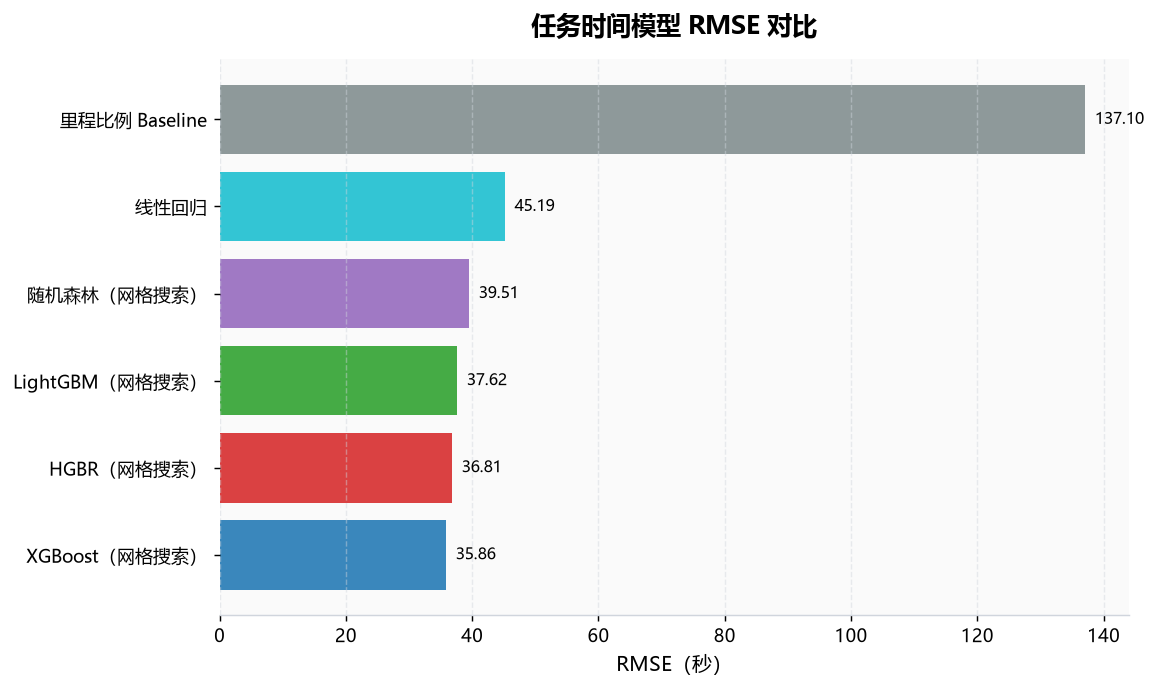

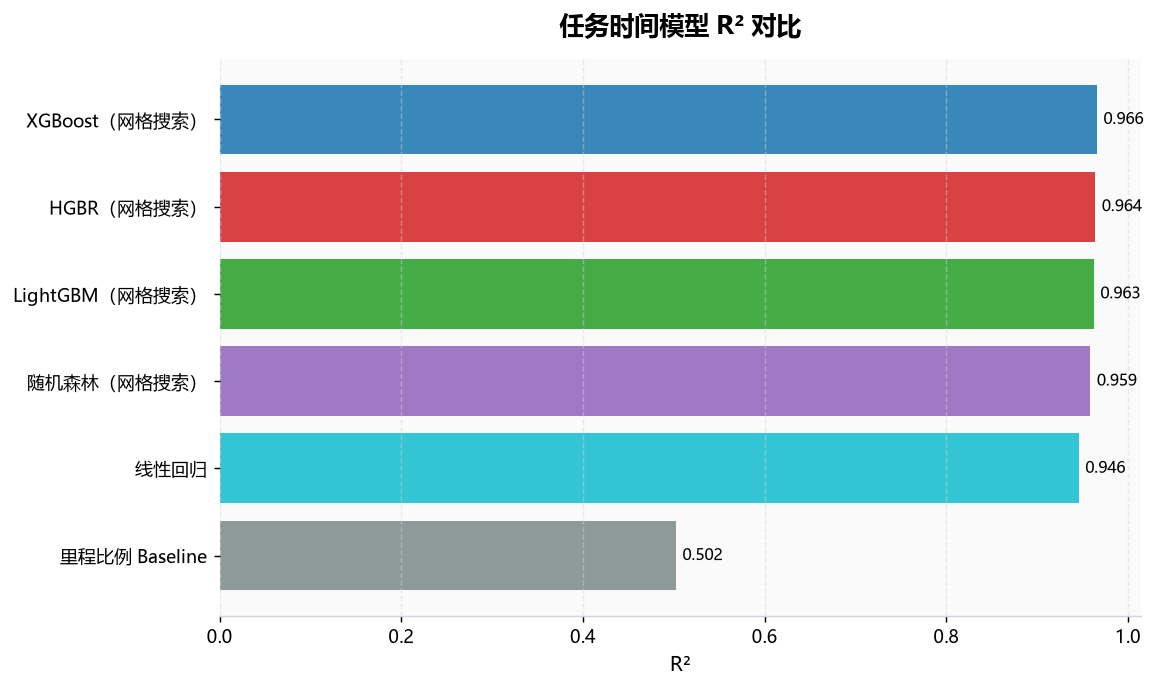

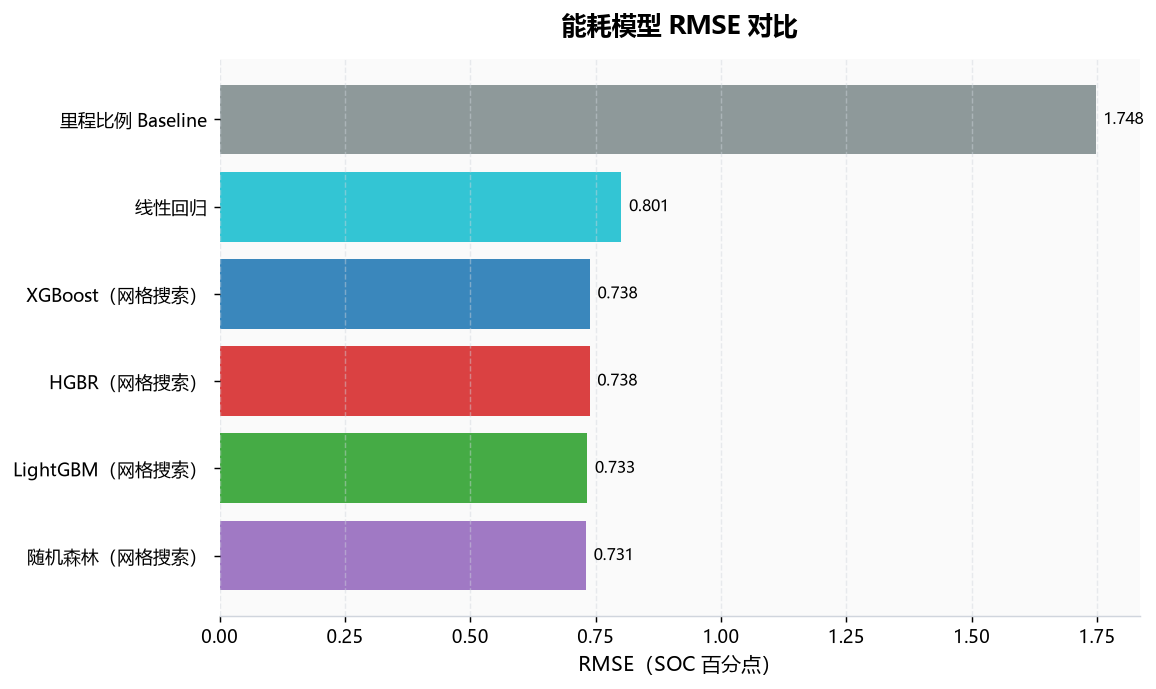

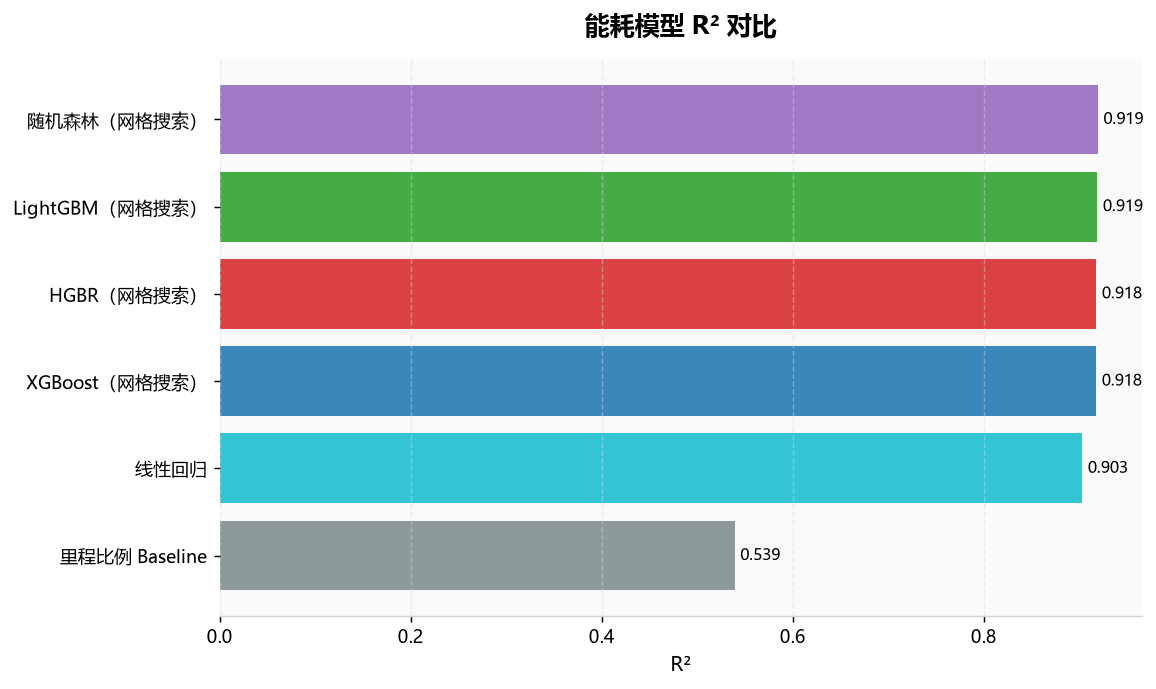

In [126]:
def plot_metric_comparison(
    comparison_df,
    metric,
    ylabel,
    title,
    decimal_places,
):
    plot_df = comparison_df.sort_values(metric).copy()
    labels = list(plot_df.index)

    colors = []
    for label in labels:
        if "XGBoost" in label:
            colors.append(MODEL_COLORS["XGBoost"])
        elif "LightGBM" in label:
            colors.append(MODEL_COLORS["LightGBM"])
        elif "HGBR" in label:
            colors.append(MODEL_COLORS["HGBR"])
        elif "随机森林" in label:
            colors.append(MODEL_COLORS["随机森林"])
        elif "线性" in label:
            colors.append("#17BECF")
        else:
            colors.append("#7F8C8D")

    fig_height = max(5.2, 0.65 * len(plot_df) + 1.5)
    fig, ax = plt.subplots(figsize=(9.0, fig_height))
    bars = ax.barh(
        labels,
        plot_df[metric],
        color=colors,
        alpha=0.88,
    )

    values = plot_df[metric].to_numpy()
    value_span = max(values.max() - values.min(), abs(values).max() * 0.1, 1e-9)

    for bar, value in zip(bars, values):
        ax.text(
            value + value_span * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.{decimal_places}f}",
            va="center",
            fontsize=9,
        )

    ax.set_xlabel(ylabel)
    ax.set_ylabel("")
    ax.set_title(title, pad=14)
    ax.grid(axis="y", visible=False)
    ax.spines[["top", "right", "left"]].set_visible(False)
    fig.tight_layout()
    plt.show()


plot_metric_comparison(
    time_comparison,
    metric="RMSE",
    ylabel="RMSE（秒）",
    title="任务时间模型 RMSE 对比",
    decimal_places=2,
)

plot_metric_comparison(
    time_comparison,
    metric="R2",
    ylabel="R²",
    title="任务时间模型 R² 对比",
    decimal_places=3,
)

plot_metric_comparison(
    energy_comparison,
    metric="RMSE",
    ylabel="RMSE（SOC 百分点）",
    title="能耗模型 RMSE 对比",
    decimal_places=3,
)

plot_metric_comparison(
    energy_comparison,
    metric="R2",
    ylabel="R²",
    title="能耗模型 R² 对比",
    decimal_places=3,
)


# 13. 可选：固定最优参数的 5 折稳定性检验

网格搜索已通过训练集交叉验证选择参数。本节是额外的模型稳定性比较，可按需要运行。

**说明**

- 里程比例模型每一折都重新计算比例系数；
- 线性回归每一折重新拟合；
- XGBoost、LightGBM、HGBR 使用各自前面搜索出的最佳参数，每一折重新拟合；
- 这不是严格的嵌套交叉验证，因此不能代替独立测试集结果。

## 13.1 创建交叉验证器和评价指标

**本单元功能**

- 创建最多 5 折的随机 K 折；
- 定义 MAE、RMSE 和 R² 三个评分指标。

In [127]:
n_splits = min(5, len(df) // 2)

if n_splits < 2:
    raise ValueError("样本数太少，无法进行交叉验证。")

cv = KFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=RANDOM_STATE,
)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}

print(f"使用 {n_splits} 折交叉验证。")

使用 5 折交叉验证。


## 13.2 计算里程比例 Baseline 的逐折结果

**本单元功能**

- 每一折只用该折训练数据计算时间和能耗比例系数；
- 在该折验证数据上计算指标；
- 保存每一折的系数和评价结果。

In [128]:
baseline1_cv_rows = []

for fold, (train_idx, valid_idx) in enumerate(
    cv.split(df),
    start=1,
):
    fold_train = df.iloc[train_idx]
    fold_valid = df.iloc[valid_idx]

    d_train = (
        fold_train["total_distance_odometer_m"]
        .to_numpy()
    )
    denominator = np.sum(d_train ** 2)

    if denominator == 0:
        raise ValueError(
            f"第 {fold} 折训练集里程全部为 0，"
            "无法拟合里程比例模型。"
        )

    t_train = fold_train[TIME_TARGET].to_numpy()
    e_train = fold_train[ENERGY_TARGET].to_numpy()

    fold_time_k = (
        np.sum(d_train * t_train)
        / denominator
    )
    fold_energy_k = (
        np.sum(d_train * e_train)
        / denominator
    )

    valid_distance = (
        fold_valid["total_distance_odometer_m"]
        .to_numpy()
    )

    fold_time_pred = fold_time_k * valid_distance
    fold_energy_pred = fold_energy_k * valid_distance

    fold_time_metrics = get_metrics(
        fold_valid[TIME_TARGET],
        fold_time_pred,
    )
    fold_energy_metrics = get_metrics(
        fold_valid[ENERGY_TARGET],
        fold_energy_pred,
    )

    baseline1_cv_rows.append({
        "fold": fold,
        "time_k_s_per_m": fold_time_k,
        "time_MAE": fold_time_metrics["MAE"],
        "time_RMSE": fold_time_metrics["RMSE"],
        "time_R2": fold_time_metrics["R2"],
        "energy_k_soc_pct_per_m": fold_energy_k,
        "energy_MAE": fold_energy_metrics["MAE"],
        "energy_RMSE": fold_energy_metrics["RMSE"],
        "energy_R2": fold_energy_metrics["R2"],
    })

baseline1_cv = pd.DataFrame(baseline1_cv_rows)
display(baseline1_cv.round(4))

,fold,time_k_s_per_m,time_MAE,time_RMSE,time_R2,energy_k_soc_pct_per_m,energy_MAE,energy_RMSE,energy_R2
0,1,0.3077,98.5729,137.0994,0.5025,0.0037,1.4137,1.7477,0.5392
1,2,0.3069,99.4823,149.9737,0.4176,0.0037,1.3779,1.6914,0.5481
2,3,0.3065,94.3225,145.1144,0.4768,0.0037,1.4452,1.7824,0.5225
3,4,0.3070,97.3593,139.9492,0.4849,0.0037,1.2797,1.5937,0.5945
4,5,0.3071,96.7458,137.1915,0.5178,0.0037,1.4088,1.7787,0.5620


## 13.3 计算线性回归和三个最优提升树模型的交叉验证结果

使用完整数据集进行固定参数交叉验证，检查模型在不同折上的稳定性。

In [129]:
linear_time_cv = cross_validate(
    LinearRegression(),
    df[FEATURE_COLS],
    df[TIME_TARGET],
    cv=cv,
    scoring=scoring,
)

linear_energy_cv = cross_validate(
    LinearRegression(),
    df[FEATURE_COLS],
    df[ENERGY_TARGET],
    cv=cv,
    scoring=scoring,
)

xgb_time_cv = cross_validate(
    XGBRegressor(
        objective="reg:squarederror",
        min_child_weight=2,
        reg_alpha=0.1,
        reg_lambda=3.0,
        random_state=RANDOM_STATE,
        n_jobs=1,
        **time_grid_search.best_params_,
    ),
    df[FEATURE_COLS],
    df[TIME_TARGET],
    cv=cv,
    scoring=scoring,
)

xgb_energy_cv = cross_validate(
    XGBRegressor(
        objective="reg:squarederror",
        min_child_weight=2,
        reg_alpha=0.1,
        reg_lambda=3.0,
        random_state=RANDOM_STATE,
        n_jobs=1,
        **energy_grid_search.best_params_,
    ),
    df[FEATURE_COLS],
    df[ENERGY_TARGET],
    cv=cv,
    scoring=scoring,
)

lgbm_time_cv = cross_validate(
    LGBMRegressor(
        objective="regression",
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbosity=-1,
        **lgbm_time_grid_search.best_params_,
    ),
    df[FEATURE_COLS],
    df[TIME_TARGET],
    cv=cv,
    scoring=scoring,
)

lgbm_energy_cv = cross_validate(
    LGBMRegressor(
        objective="regression",
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbosity=-1,
        **lgbm_energy_grid_search.best_params_,
    ),
    df[FEATURE_COLS],
    df[ENERGY_TARGET],
    cv=cv,
    scoring=scoring,
)

hgbr_time_cv = cross_validate(
    HistGradientBoostingRegressor(
        loss="squared_error",
        early_stopping=False,
        random_state=RANDOM_STATE,
        **hgbr_time_grid_search.best_params_,
    ),
    df[FEATURE_COLS],
    df[TIME_TARGET],
    cv=cv,
    scoring=scoring,
)

hgbr_energy_cv = cross_validate(
    HistGradientBoostingRegressor(
        loss="squared_error",
        early_stopping=False,
        random_state=RANDOM_STATE,
        **hgbr_energy_grid_search.best_params_,
    ),
    df[FEATURE_COLS],
    df[ENERGY_TARGET],
    cv=cv,
    scoring=scoring,
)


rf_time_cv = cross_validate(
    RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=1,
        **rf_time_grid_search.best_params_,
    ),
    df[FEATURE_COLS],
    df[TIME_TARGET],
    cv=cv,
    scoring=scoring,
)

rf_energy_cv = cross_validate(
    RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=1,
        **rf_energy_grid_search.best_params_,
    ),
    df[FEATURE_COLS],
    df[ENERGY_TARGET],
    cv=cv,
    scoring=scoring,
)

print("交叉验证完成。")


交叉验证完成。


## 13.4 汇总交叉验证平均指标

**本单元功能**

- 计算各模型跨折平均 MAE、RMSE 和 R²；
- 分别生成时间预测和能耗预测的稳定性对比表。

In [130]:
time_cv_comparison = pd.DataFrame([
    {
        "model": "里程比例 Baseline",
        "CV_MAE": baseline1_cv["time_MAE"].mean(),
        "CV_RMSE": baseline1_cv["time_RMSE"].mean(),
        "CV_R2": baseline1_cv["time_R2"].mean(),
    },
    {
        "model": "线性回归",
        "CV_MAE": -linear_time_cv["test_MAE"].mean(),
        "CV_RMSE": -linear_time_cv["test_RMSE"].mean(),
        "CV_R2": linear_time_cv["test_R2"].mean(),
    },
    {
        "model": "XGBoost（网格搜索）",
        "CV_MAE": -xgb_time_cv["test_MAE"].mean(),
        "CV_RMSE": -xgb_time_cv["test_RMSE"].mean(),
        "CV_R2": xgb_time_cv["test_R2"].mean(),
    },
    {
        "model": "LightGBM（网格搜索）",
        "CV_MAE": -lgbm_time_cv["test_MAE"].mean(),
        "CV_RMSE": -lgbm_time_cv["test_RMSE"].mean(),
        "CV_R2": lgbm_time_cv["test_R2"].mean(),
    },
    {
        "model": "HGBR（网格搜索）",
        "CV_MAE": -hgbr_time_cv["test_MAE"].mean(),
        "CV_RMSE": -hgbr_time_cv["test_RMSE"].mean(),
        "CV_R2": hgbr_time_cv["test_R2"].mean(),
    },
    {
        "model": "随机森林（网格搜索）",
        "CV_MAE": -rf_time_cv["test_MAE"].mean(),
        "CV_RMSE": -rf_time_cv["test_RMSE"].mean(),
        "CV_R2": rf_time_cv["test_R2"].mean(),
    },
]).set_index("model")

energy_cv_comparison = pd.DataFrame([
    {
        "model": "里程比例 Baseline",
        "CV_MAE": baseline1_cv["energy_MAE"].mean(),
        "CV_RMSE": baseline1_cv["energy_RMSE"].mean(),
        "CV_R2": baseline1_cv["energy_R2"].mean(),
    },
    {
        "model": "线性回归",
        "CV_MAE": -linear_energy_cv["test_MAE"].mean(),
        "CV_RMSE": -linear_energy_cv["test_RMSE"].mean(),
        "CV_R2": linear_energy_cv["test_R2"].mean(),
    },
    {
        "model": "XGBoost（网格搜索）",
        "CV_MAE": -xgb_energy_cv["test_MAE"].mean(),
        "CV_RMSE": -xgb_energy_cv["test_RMSE"].mean(),
        "CV_R2": xgb_energy_cv["test_R2"].mean(),
    },
    {
        "model": "LightGBM（网格搜索）",
        "CV_MAE": -lgbm_energy_cv["test_MAE"].mean(),
        "CV_RMSE": -lgbm_energy_cv["test_RMSE"].mean(),
        "CV_R2": lgbm_energy_cv["test_R2"].mean(),
    },
    {
        "model": "HGBR（网格搜索）",
        "CV_MAE": -hgbr_energy_cv["test_MAE"].mean(),
        "CV_RMSE": -hgbr_energy_cv["test_RMSE"].mean(),
        "CV_R2": hgbr_energy_cv["test_R2"].mean(),
    },
    {
        "model": "随机森林（网格搜索）",
        "CV_MAE": -rf_energy_cv["test_MAE"].mean(),
        "CV_RMSE": -rf_energy_cv["test_RMSE"].mean(),
        "CV_R2": rf_energy_cv["test_R2"].mean(),
    },
]).set_index("model")

print("任务时间交叉验证平均结果：")
display(time_cv_comparison.round(4))

print("能耗交叉验证平均结果：")
display(energy_cv_comparison.round(4))


任务时间交叉验证平均结果：


,CV_MAE,CV_RMSE,CV_R2
model,,,
里程比例 Baseline,97.2966,141.8656,0.4799
线性回归,33.1065,46.8341,0.9433
XGBoost（网格搜索）,24.4050,33.8955,0.9702
LightGBM（网格搜索）,25.1548,35.6696,0.9670
HGBR（网格搜索）,25.1470,35.7055,0.9669
随机森林（网格搜索）,26.4479,38.3983,0.9617


能耗交叉验证平均结果：


,CV_MAE,CV_RMSE,CV_R2
model,,,
里程比例 Baseline,1.3851,1.7188,0.5533
线性回归,0.6052,0.7958,0.9042
XGBoost（网格搜索）,0.5801,0.7507,0.9148
LightGBM（网格搜索）,0.5738,0.7434,0.9164
HGBR（网格搜索）,0.5745,0.7435,0.9164
随机森林（网格搜索）,0.5735,0.7410,0.9170


## 13.5 绘制交叉验证 R² 对比图

**本单元功能**

- 绘制时间模型平均交叉验证 R²；
- 绘制能耗模型平均交叉验证 R²。

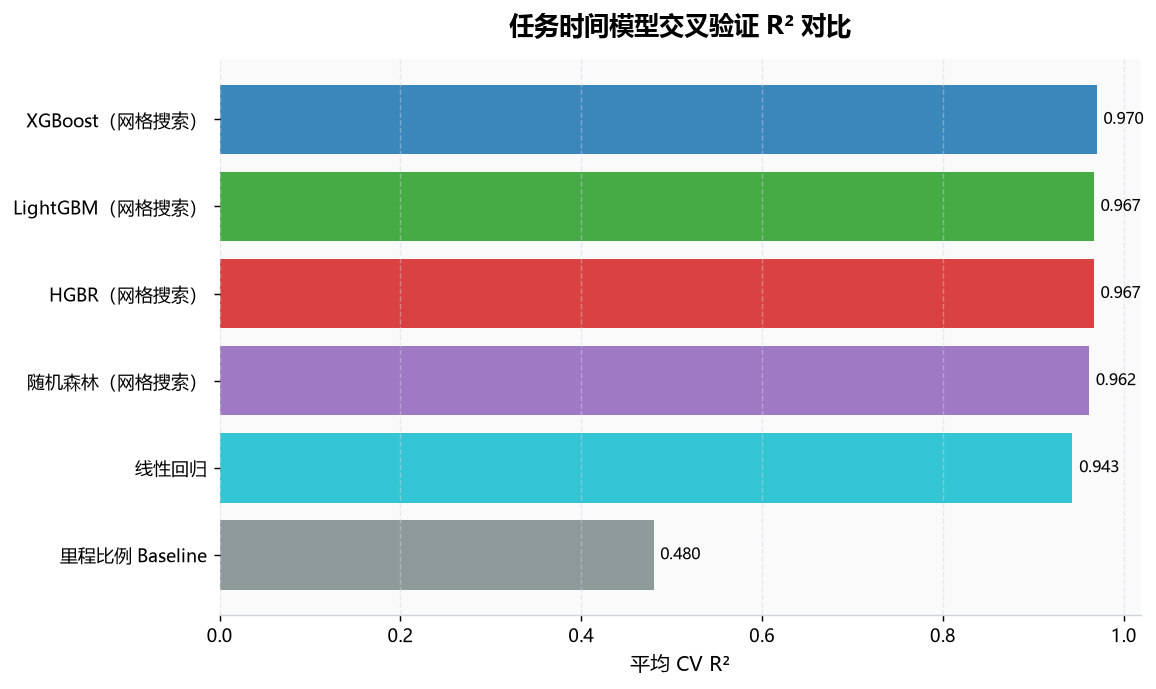

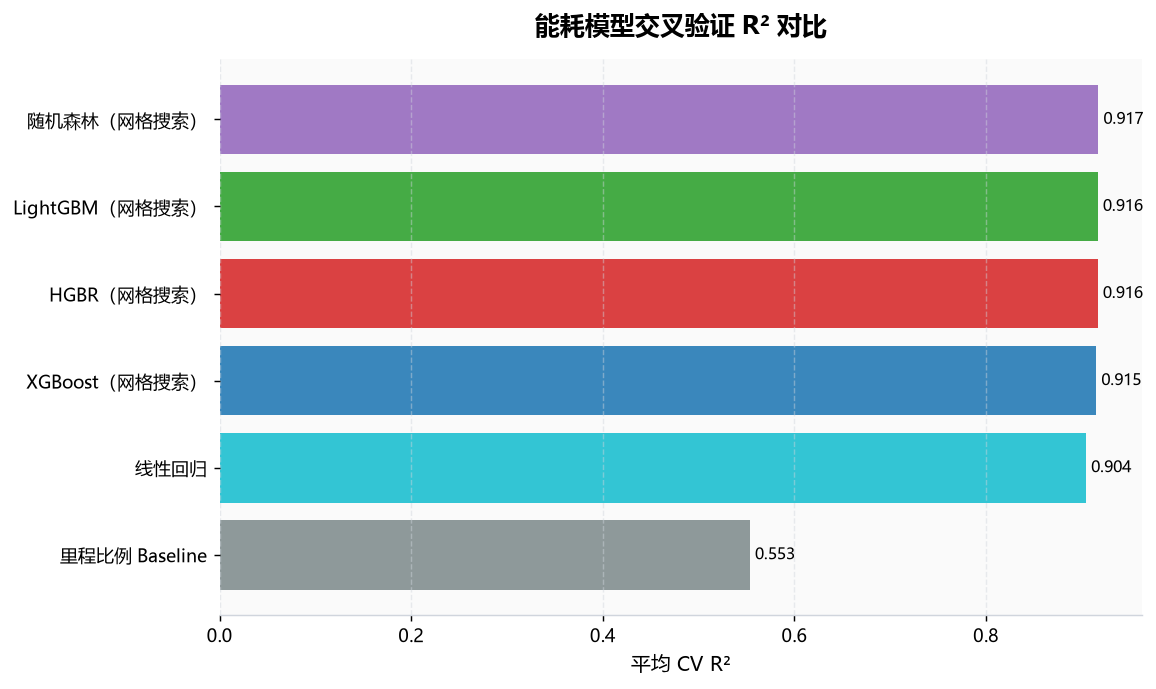

In [131]:
plot_metric_comparison(
    time_cv_comparison,
    metric="CV_R2",
    ylabel="平均 CV R²",
    title="任务时间模型交叉验证 R² 对比",
    decimal_places=3,
)

plot_metric_comparison(
    energy_cv_comparison,
    metric="CV_R2",
    ylabel="平均 CV R²",
    title="能耗模型交叉验证 R² 对比",
    decimal_places=3,
)

# 14. 保存模型、参数、搜索结果和预测结果

保存所有模型、最优参数、完整网格搜索结果、测试集预测值和评价指标。

In [132]:
# 1. 保存里程比例模型
baseline1_model_path = (
    OUTPUT_DIR
    / "baseline1_distance_time_energy_model.json"
)

with baseline1_model_path.open("w", encoding="utf-8") as file:
    json.dump(
        baseline1_model_data,
        file,
        ensure_ascii=False,
        indent=2,
    )


# 2. 保存线性回归模型
joblib.dump(
    linear_time_model,
    OUTPUT_DIR / "linear_time_model.joblib",
)
joblib.dump(
    linear_energy_model,
    OUTPUT_DIR / "linear_energy_model.joblib",
)


# 3. 保存网格搜索后的最优树模型
joblib.dump(
    xgb_time_model,
    OUTPUT_DIR / "xgboost_time_grid_search_model.joblib",
)
joblib.dump(
    xgb_energy_model,
    OUTPUT_DIR / "xgboost_energy_grid_search_model.joblib",
)
joblib.dump(
    lgbm_time_model,
    OUTPUT_DIR / "lightgbm_time_grid_search_model.joblib",
)
joblib.dump(
    lgbm_energy_model,
    OUTPUT_DIR / "lightgbm_energy_grid_search_model.joblib",
)
joblib.dump(
    hgbr_time_model,
    OUTPUT_DIR / "hgbr_time_grid_search_model.joblib",
)
joblib.dump(
    hgbr_energy_model,
    OUTPUT_DIR / "hgbr_energy_grid_search_model.joblib",
)
joblib.dump(
    rf_time_model,
    OUTPUT_DIR / "random_forest_time_grid_search_model.joblib",
)
joblib.dump(
    rf_energy_model,
    OUTPUT_DIR / "random_forest_energy_grid_search_model.joblib",
)


# 4. 保存各模型的最优参数和最优 CV RMSE
best_grid_parameters = {
    "xgboost": {
        "time_best_params": time_grid_search.best_params_,
        "time_best_cv_rmse": -time_grid_search.best_score_,
        "energy_best_params": energy_grid_search.best_params_,
        "energy_best_cv_rmse": -energy_grid_search.best_score_,
    },
    "lightgbm": {
        "time_best_params": lgbm_time_grid_search.best_params_,
        "time_best_cv_rmse": -lgbm_time_grid_search.best_score_,
        "energy_best_params": lgbm_energy_grid_search.best_params_,
        "energy_best_cv_rmse": -lgbm_energy_grid_search.best_score_,
    },
    "hgbr": {
        "time_best_params": hgbr_time_grid_search.best_params_,
        "time_best_cv_rmse": -hgbr_time_grid_search.best_score_,
        "energy_best_params": hgbr_energy_grid_search.best_params_,
        "energy_best_cv_rmse": -hgbr_energy_grid_search.best_score_,
    },
    "random_forest": {
        "time_best_params": rf_time_grid_search.best_params_,
        "time_best_cv_rmse": -rf_time_grid_search.best_score_,
        "energy_best_params": rf_energy_grid_search.best_params_,
        "energy_best_cv_rmse": -rf_energy_grid_search.best_score_,
    },
}

with (
    OUTPUT_DIR / "boosting_grid_search_best_parameters.json"
).open("w", encoding="utf-8") as file:
    json.dump(
        best_grid_parameters,
        file,
        ensure_ascii=False,
        indent=2,
    )


# 5. 保存完整网格搜索结果
search_result_files = {
    "xgboost_time_grid_search_results.csv": time_grid_results,
    "xgboost_energy_grid_search_results.csv": energy_grid_results,
    "lightgbm_time_grid_search_results.csv": lgbm_time_grid_results,
    "lightgbm_energy_grid_search_results.csv": lgbm_energy_grid_results,
    "hgbr_time_grid_search_results.csv": hgbr_time_grid_results,
    "hgbr_energy_grid_search_results.csv": hgbr_energy_grid_results,
    "random_forest_time_grid_search_results.csv": rf_time_grid_results,
    "random_forest_energy_grid_search_results.csv": rf_energy_grid_results,
}

for file_name, result_df in search_result_files.items():
    result_df.to_csv(
        OUTPUT_DIR / file_name,
        index=False,
        encoding="utf-8-sig",
    )


# 6. 保存测试集逐条预测
prediction_result = test_df[
    [
        "task_id",
        "task_index",
        "source_file",
        "total_distance_odometer_m",
        TIME_TARGET,
        ENERGY_TARGET,
    ]
].copy()

prediction_result["baseline1_time_pred_s"] = baseline1_time_pred
prediction_result["baseline1_energy_pred_pct"] = baseline1_energy_pred
prediction_result["linear_time_pred_s"] = linear_time_pred
prediction_result["linear_energy_pred_pct"] = linear_energy_pred
prediction_result["xgboost_time_grid_pred_s"] = xgb_time_pred
prediction_result["xgboost_energy_grid_pred_pct"] = xgb_energy_pred
prediction_result["lightgbm_time_grid_pred_s"] = lgbm_time_pred
prediction_result["lightgbm_energy_grid_pred_pct"] = lgbm_energy_pred
prediction_result["hgbr_time_grid_pred_s"] = hgbr_time_pred
prediction_result["hgbr_energy_grid_pred_pct"] = hgbr_energy_pred
prediction_result["random_forest_time_grid_pred_s"] = rf_time_pred
prediction_result["random_forest_energy_grid_pred_pct"] = rf_energy_pred

prediction_result.to_csv(
    OUTPUT_DIR / "test_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)


# 7. 保存评价指标
time_comparison.to_csv(
    OUTPUT_DIR / "time_test_metrics.csv",
    encoding="utf-8-sig",
)

energy_comparison.to_csv(
    OUTPUT_DIR / "energy_test_metrics.csv",
    encoding="utf-8-sig",
)

# 仅当已运行第 13 节时，保存交叉验证指标
if "time_cv_comparison" in globals():
    time_cv_comparison.to_csv(
        OUTPUT_DIR / "time_cross_validation_metrics.csv",
        encoding="utf-8-sig",
    )

if "energy_cv_comparison" in globals():
    energy_cv_comparison.to_csv(
        OUTPUT_DIR / "energy_cross_validation_metrics.csv",
        encoding="utf-8-sig",
    )

print("全部结果已保存到：", OUTPUT_DIR)
display(prediction_result.head(10).round(4))


全部结果已保存到： C:\Users\14993\PycharmProjects\BoLei-DataMining\target\ModelResults


,task_id,task_index,source_file,total_distance_odometer_m,task_duration_s,total_energy_soc_delta_pct,baseline1_time_pred_s,baseline1_energy_pred_pct,linear_time_pred_s,linear_energy_pred_pct,xgboost_time_grid_pred_s,xgboost_energy_grid_pred_pct,lightgbm_time_grid_pred_s,lightgbm_energy_grid_pred_pct,hgbr_time_grid_pred_s,hgbr_energy_grid_pred_pct,random_forest_time_grid_pred_s,random_forest_energy_grid_pred_pct
0,8065986810708225,51,TLE00860HR1450010卸料任务_特征和标签.json,3375.0,1002.1024,14.4,1038.3783,12.5795,1042.6817,14.1067,1003.553589,13.838400,1016.7142,13.7576,1010.3315,13.8784,1023.1249,13.7240
1,8066176061194497,57,TLE00900CR1450050卸料任务_特征和标签.json,4375.0,1409.4458,18.4,1346.0459,16.3067,1376.1965,17.1633,1391.834839,17.809700,1413.3760,17.7924,1395.2867,17.7915,1398.7319,17.7160
2,8094951438336257,101,TLE00900VR1450048最终有效卸货记录615-707_sorted_特征和标签....,3250.0,1025.8506,13.2,999.9198,12.1136,1070.7872,11.4144,1022.140991,11.278400,1046.6661,11.3307,1034.8163,11.2913,1056.8594,11.3893
3,8062584127078657,14,TLE00900JR1450046卸料任务_特征和标签.json,3250.0,1140.1710,13.6,999.9198,12.1136,1100.2404,13.7680,1128.320435,13.845000,1136.5228,13.7835,1140.9378,13.7824,1117.9399,13.8573
4,8099212179472641,143,TLE00860VR1450018最终有效卸货记录615-707_sorted_特征和标签....,3500.0,1194.9745,12.0,1076.8368,13.0454,1279.0431,11.9360,1241.732300,11.794100,1234.6757,11.7890,1218.5620,11.8025,1219.5533,11.7680
5,8066256954654977,57,TLE00900AR1450052卸料任务_特征和标签.json,5250.0,1426.3102,18.0,1615.2551,19.5681,1407.9727,16.9514,1423.421875,17.300301,1435.0142,17.2413,1429.4311,17.3569,1428.0503,17.3707
6,8087961773113601,34,TLE00860HR1450010最终有效卸货记录615-707_sorted_特征和标签....,4125.0,1113.0407,12.8,1269.1290,15.3749,1055.5481,12.9744,1081.908691,12.910900,1090.1096,12.9560,1098.5716,12.9846,1109.4773,13.1160
7,8101046186524929,184,TLE00900CR1450050最终有效卸货记录615-707_sorted_特征和标签....,3125.0,1303.7853,12.8,961.4614,11.6477,1305.0034,13.0494,1311.130615,13.108100,1252.5686,13.0821,1304.2090,13.2204,1280.4462,13.0773
8,8065180703752449,41,TLE00860HR1450010卸料任务_特征和标签.json,3875.0,1203.6099,16.8,1192.2121,14.4431,1237.8313,16.1503,1194.639648,16.322800,1199.3036,16.4369,1196.1010,16.5310,1200.5137,16.2360
9,8085294128709889,7,TLE00900AR1450049最终有效卸货记录615-707_sorted_特征和标签....,4375.0,1291.9774,17.6,1346.0459,16.3067,1302.4970,17.5049,1330.602783,17.870199,1334.0403,17.5891,1323.1815,17.8421,1321.3722,17.6693


# 15. 结果阅读顺序

建议按以下顺序检查结果：

1. 查看 XGBoost、LightGBM 和 HGBR 的最优参数及训练集 CV RMSE；
2. 查看测试集统一比较表中的 MAE、RMSE 和 R²；
3. 检查真实值—预测值图是否接近对角线；
4. 检查残差是否围绕 0 随机分布；
5. 查看 XGBoost 和 LightGBM 的特征重要性；
6. 根据需要运行第 13 节，检查固定最优参数下的跨折稳定性。

注意：

- 测试集不能用于选择参数；
- 网格搜索只能找到当前候选范围内的最优组合；
- 可以围绕第一轮最优参数设置更细的第二轮网格；
- 如果目标是发车前预测，应检查 `speed_mean`、`speed_std` 等全程统计特征是否造成信息泄漏；
- 当前 Notebook 仍沿用原来的随机训练/测试划分和 KFold，如使用历史滚动特征，建议后续改为按时间排序划分。